Processing 200 data points in 10 batches of size 20...


100%|██████████| 10/10 [00:00<00:00, 907.68it/s]


--- Finished processing all batches ---


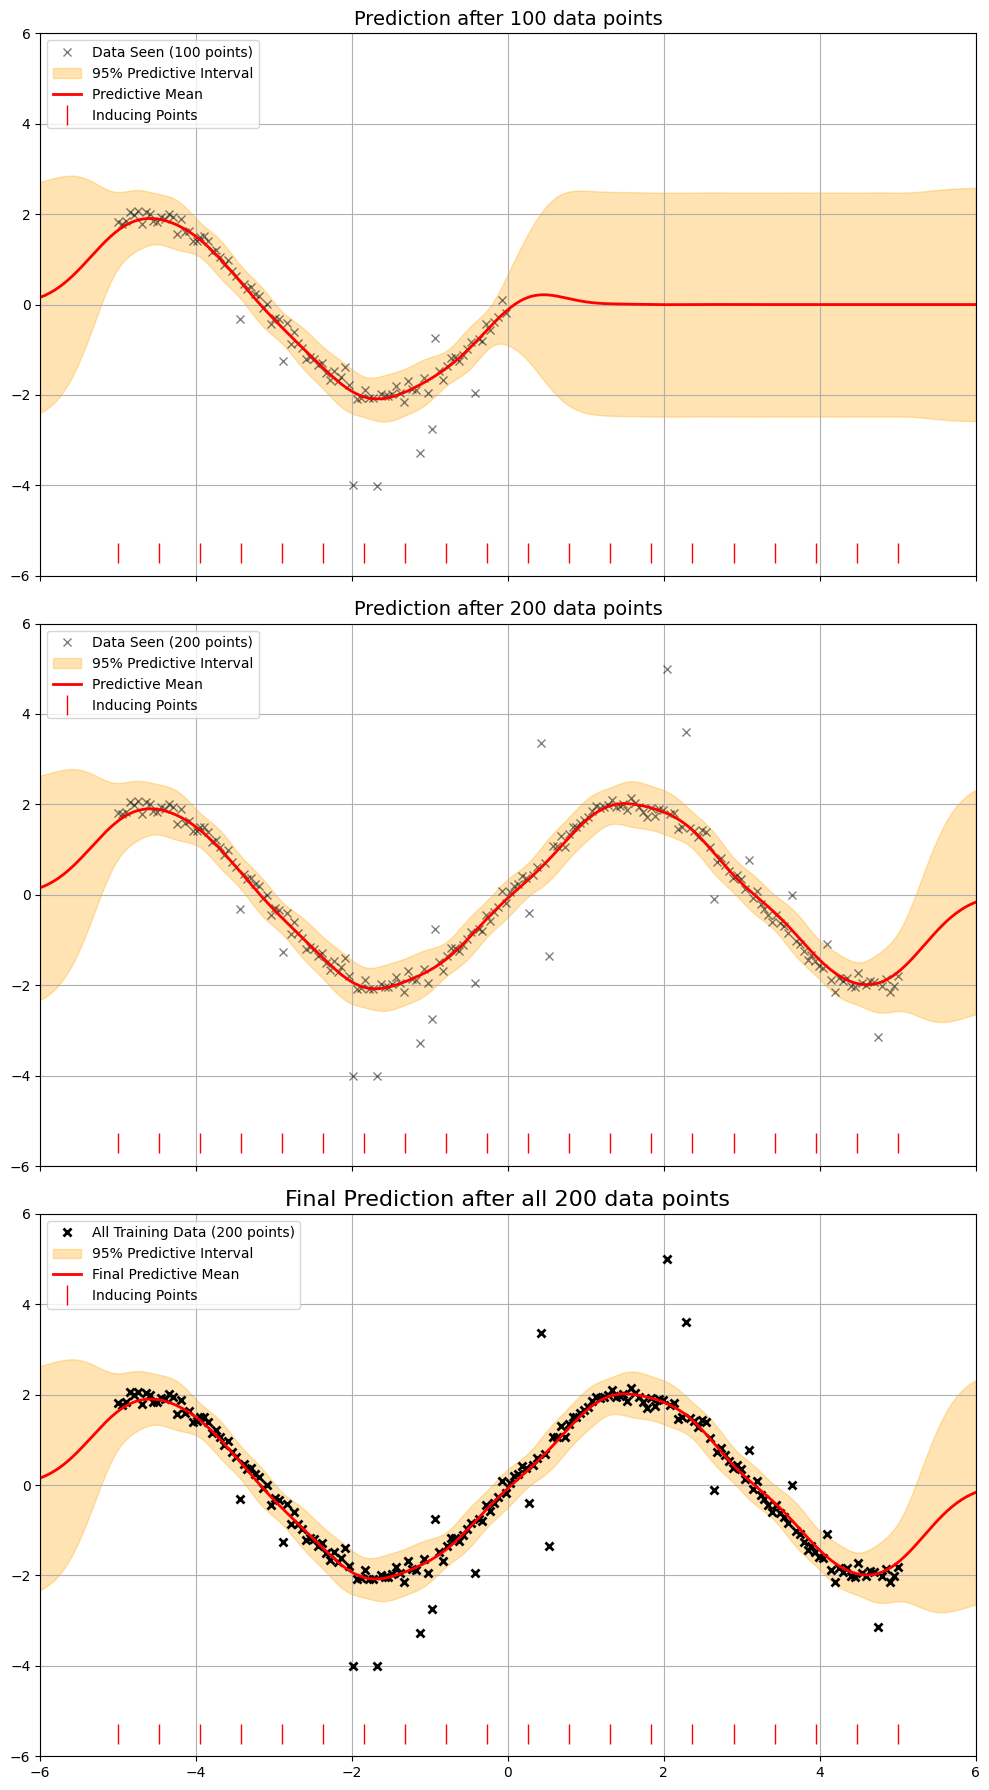

In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class StreamingTPRegression(nn.Module):
    """
    Implements a streaming/online version of the TP Regression model.

    This class processes data in minibatches. It maintains the posterior over
    global latent variables (u, r) and updates them as new data arrives.
    Local variables (lambda_i) are inferred for each batch and then discarded.
    Hyperparameters and inducing points (Z) are treated as fixed after initialization.
    """
    def __init__(self, M, D, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.M = M
        self.D = D

        # --- Hyperparameters and Inducing Points (fixed in streaming setting) ---
        self.register_buffer('Z', Z_initial.clone())
        self.kernel_lengthscale = torch.tensor(kernel_lengthscale)
        self.kernel_variance = torch.tensor(kernel_variance)
        self.sigma_sq = torch.tensor(likelihood_sigma**2)
        self.nu_f = torch.tensor(nu_f)
        self.nu_e = torch.tensor(nu_e)

        # --- Global Variational Parameters ---
        # These are updated with each minibatch.
        # For q(u) = N(m_u, S_u), we store natural parameters for easier updates.
        # P_u = S_u^-1 (Precision Matrix)
        # h_u = S_u^-1 * m_u
        self.h_u_data = torch.zeros(self.M, 1) # Data contribution to h_u
        self.P_u_data = torch.zeros(self.M, self.M) # Data contribution to P_u

        # For q(r) = Gamma(alpha_r, beta_r)
        # alpha_r is updated once at initialization based on the prior.
        self.alpha_r = self.nu_f / 2.0 + self.M / 2.0
        self.beta_r = self.nu_f / 2.0 # Initial value from prior

    def kernel(self, A, B):
        """ RBF kernel """
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return self.kernel_variance * torch.exp(-0.5 * sq_dist / self.kernel_lengthscale.pow(2))

    def get_global_posterior_q_u(self):
        """
        Computes the current global posterior q(u) from its natural parameters
        and the current expectation of r.
        """
        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Kzz_inv = torch.inverse(Kzz)
        E_r = self.alpha_r / self.beta_r

        # Combine prior and data contributions to get full precision matrix
        P_u_prior = E_r * Kzz_inv
        P_u = P_u_prior + self.P_u_data

        # Cholesky decomposition for stable inversion
        L_P = torch.linalg.cholesky(P_u)
        S_u = torch.cholesky_solve(torch.eye(self.M), L_P)
        m_u = S_u @ self.h_u_data

        return m_u, S_u

    def partial_fit(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Processes a single minibatch of data to update the global variational posterior.
        This is the core of the streaming algorithm.
        """
        N_batch = X_batch.shape[0]

        # --- E-Step: Infer local and batch-level parameters ---
        # We run a local CAVI loop for the minibatch.

        # 1. Get current global posterior q(u) to calculate expectations for f
        m_u_global, S_u_global = self.get_global_posterior_q_u()
        L_u_global = torch.linalg.cholesky(S_u_global + torch.eye(self.M) * 1e-6)

        # 2. Precompute kernel matrices for the batch
        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(X_batch, self.Z)
        Kxx_diag_batch = self.kernel(X_batch, X_batch).diag()

        # 3. Initialize local variational parameters for the batch
        alpha_lambda_batch = torch.ones(N_batch, 1)
        beta_lambda_batch = torch.ones(N_batch, 1)

        # 4. Run CAVI loop for the minibatch
        for _ in range(cavi_max_iter):
            alpha_lambda_old = alpha_lambda_batch.clone()

            # --- Calculate expectations needed for updates ---
            # E[f_batch] and Var(f_batch) under the *current global* posterior
            Kzz_inv_mu_global = torch.cholesky_solve(m_u_global, Lzz)
            E_q_f_batch = Kxz_batch @ Kzz_inv_mu_global

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
            A_batch = torch.linalg.solve(Kzz, Kxz_batch.T).T
            var_f_inducing = torch.sum((A_batch @ L_u_global)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag_batch - torch.sum(A_batch * Kxz_batch, dim=1))
            Var_q_f_batch = (var_f_prior + var_f_inducing).unsqueeze(1)

            # --- Update local q(lambda_i) for the batch ---
            alpha_lambda_batch = self.nu_e / 2.0 + 0.5
            expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
            beta_lambda_batch = self.nu_e / 2.0 + (1.0 / (2.0 * self.sigma_sq)) * expected_sq_error

            # Check for convergence of local parameters
            change = torch.norm(alpha_lambda_batch - alpha_lambda_old)
            if change < cavi_tol:
                break

        # --- M-Step: Update global parameters using the batch results ---

        # 1. Calculate the contribution (sufficient statistics) from this batch to q(u)
        E_lambda_batch = alpha_lambda_batch / beta_lambda_batch
        
        # Contribution to the precision matrix P_u
        P_u_batch = A_batch.T @ (E_lambda_batch * A_batch) / self.sigma_sq
        
        # Contribution to h_u = P_u * m_u
        h_u_batch = (A_batch.T * E_lambda_batch.T) @ y_batch / self.sigma_sq

        # 2. Additively update the data-dependent parts of the global natural parameters
        self.P_u_data += P_u_batch
        self.h_u_data += h_u_batch

        # 3. Update global q(r) using the new global q(u)
        # This update depends on the full history of data via the updated q(u)
        m_u_new, S_u_new = self.get_global_posterior_q_u()
        Kzz_inv_Su_new = torch.cholesky_solve(S_u_new, Lzz)
        Kzz_inv_mu_new = torch.cholesky_solve(m_u_new, Lzz)

        trace_term = torch.trace(Kzz_inv_Su_new)
        quad_form_term = m_u_new.T @ Kzz_inv_mu_new
        E_quad_form_u = trace_term + quad_form_term
        
        self.beta_r = self.nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def predict(self, X_test):
        """ Makes predictions at new points X_test using the current global posterior. """
        with torch.no_grad():
            m_u_final, S_u_final = self.get_global_posterior_q_u()
            L_u_final = torch.linalg.cholesky(S_u_final + torch.eye(self.M) * 1e-6)

            K_star_z = self.kernel(X_test, self.Z)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            Kzz_inv_mu = torch.cholesky_solve(m_u_final, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ L_u_final)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            pred_nu = 2 * self.alpha_r

            return pred_mean, pred_var.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # 1. Generate data
    N_total = 200
    X_full = torch.linspace(-5, 5, N_total).unsqueeze(1)
    y_true = torch.sin(X_full) * 2
    noise = torch.randn(N_total, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N_total, 1)) * 0.5
    y_full = y_true + noise
    outlier_indices = torch.randperm(N_total)[:20]
    y_full[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_full[60] = -4.0
    y_full[140] = 5.0

    # 2. Setup the streaming model
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    streaming_model = StreamingTPRegression(
        M=M,
        D=1,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Process data in a streaming fashion
    batch_size = 20
    num_batches = N_total // batch_size
    
    print(f"Processing {N_total} data points in {num_batches} batches of size {batch_size}...")
    
    # Keep track of predictions over time
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    predictions_over_time = []

    pbar = tqdm.trange(num_batches)
    for i in pbar:
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size
        X_batch = X_full[start_idx:end_idx]
        y_batch = y_full[start_idx:end_idx]

        streaming_model.partial_fit(X_batch, y_batch)
        
        # Optional: store prediction at this stage
        if (i + 1) % 5 == 0:
             pred_mean, pred_var, pred_nu = streaming_model.predict(X_test)
             predictions_over_time.append((pred_mean, pred_var, pred_nu))

    print("\n--- Finished processing all batches ---")

    # 4. Visualize the final result and the evolution
    num_plots = len(predictions_over_time) + 1
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 6 * num_plots), sharex=True)
    
    for i, (pred_mean, pred_var, pred_nu) in enumerate(predictions_over_time):
        ax = axes[i]
        
        # Plot data seen so far
        points_seen = (i + 1) * 5 * batch_size
        ax.plot(X_full[:points_seen], y_full[:points_seen], 'kx', mew=1, alpha=0.5, label=f'Data Seen ({points_seen} points)')
        
        pred_scale = torch.sqrt(pred_var)
        df = pred_nu.item()
        lower_quantile = t.ppf(0.025, df=df)
        upper_quantile = t.ppf(0.975, df=df)
        lower = pred_mean + lower_quantile * pred_scale
        upper = pred_mean + upper_quantile * pred_scale

        ax.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
        ax.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
        ax.plot(streaming_model.Z, torch.full_like(streaming_model.Z, -5.5), 'r|', ms=15, label='Inducing Points')

        ax.set_title(f'Prediction after {points_seen} data points', fontsize=14)
        ax.legend(loc='upper left')
        ax.grid(True)
        ax.set_ylim(-6, 6)

    # Final plot with all data
    ax = axes[-1]
    pred_mean_final, pred_var_final, pred_nu_final = streaming_model.predict(X_test)
    pred_scale_final = torch.sqrt(pred_var_final)
    df_final = pred_nu_final.item()
    lower_final = pred_mean_final + t.ppf(0.025, df=df_final) * pred_scale_final
    upper_final = pred_mean_final + t.ppf(0.975, df=df_final) * pred_scale_final

    ax.plot(X_full, y_full, 'kx', mew=2, label=f'All Training Data ({N_total} points)')
    ax.fill_between(X_test.squeeze(), lower_final.squeeze(), upper_final.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    ax.plot(X_test, pred_mean_final, 'r-', lw=2, label='Final Predictive Mean')
    ax.plot(streaming_model.Z, torch.full_like(streaming_model.Z, -5.5), 'r|', ms=15, label='Inducing Points')
    ax.set_title(f'Final Prediction after all {N_total} data points', fontsize=16)
    ax.legend(loc='upper left')
    ax.grid(True)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)

    plt.tight_layout()
    plt.show()



Processing 200 data points in 10 batches of size 20...


100%|██████████| 10/10 [00:00<00:00, 1235.22it/s]


--- Finished processing all batches ---


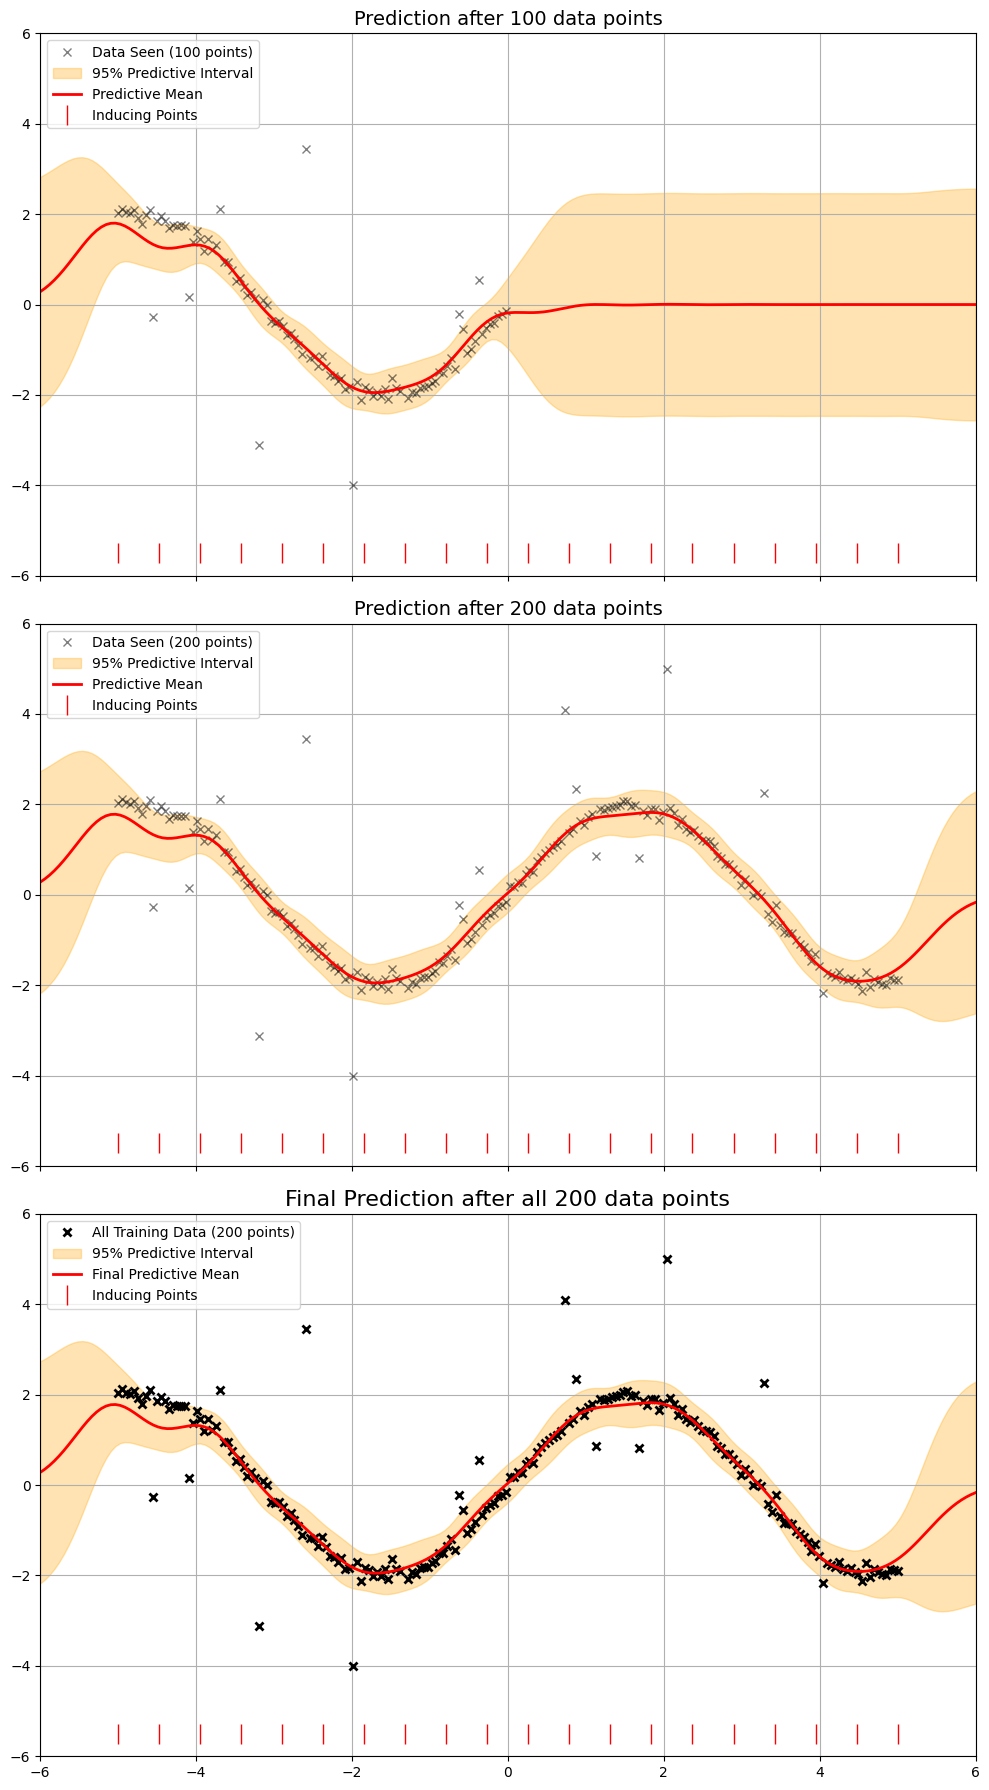

In [6]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class StreamingTPRegression(nn.Module):
    """
    Implements a streaming/online version of the TP Regression model.

    This class processes data in minibatches. It maintains the posterior over
    global latent variables (u, r) and updates them as new data arrives.
    Local variables (lambda_i) are inferred for each batch and then discarded.
    Hyperparameters and inducing points (Z) are treated as fixed after initialization.
    """
    def __init__(self, M, D, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.M = M
        self.D = D

        # --- Hyperparameters and Inducing Points (fixed in streaming setting) ---
        self.register_buffer('Z', Z_initial.clone())
        self.kernel_lengthscale = torch.tensor(kernel_lengthscale)
        self.kernel_variance = torch.tensor(kernel_variance)
        self.sigma_sq = torch.tensor(likelihood_sigma**2)
        self.nu_f = torch.tensor(nu_f)
        self.nu_e = torch.tensor(nu_e)

        # --- Global Variational Parameters ---
        # These are updated with each minibatch.
        # For q(u) = N(m_u, S_u), we store natural parameters for easier updates.
        # P_u = S_u^-1 (Precision Matrix)
        # h_u = S_u^-1 * m_u
        self.h_u_data = torch.zeros(self.M, 1) # Data contribution to h_u
        self.P_u_data = torch.zeros(self.M, self.M) # Data contribution to P_u

        # For q(r) = Gamma(alpha_r, beta_r)
        # alpha_r is updated once at initialization based on the prior.
        self.alpha_r = self.nu_f / 2.0 + self.M / 2.0
        self.beta_r = self.nu_f / 2.0 # Initial value from prior

    def kernel(self, A, B):
        """ RBF kernel """
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return self.kernel_variance * torch.exp(-0.5 * sq_dist / self.kernel_lengthscale.pow(2))

    def get_global_posterior_q_u(self):
        """
        Computes the current global posterior q(u) from its natural parameters
        and the current expectation of r.
        """
        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Kzz_inv = torch.inverse(Kzz)
        E_r = self.alpha_r / self.beta_r

        # Combine prior and data contributions to get full precision matrix
        P_u_prior = E_r * Kzz_inv
        P_u = P_u_prior + self.P_u_data

        # Cholesky decomposition for stable inversion
        L_P = torch.linalg.cholesky(P_u)
        S_u = torch.cholesky_solve(torch.eye(self.M), L_P)
        m_u = S_u @ self.h_u_data

        return m_u, S_u

    def partial_fit(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Processes a single minibatch of data to update the global variational posterior.
        This is the core of the streaming algorithm.
        """
        N_batch = X_batch.shape[0]

        # --- E-Step: Infer local and batch-level parameters ---
        # We run a local CAVI loop for the minibatch.

        # 1. Get current global posterior q(u) to calculate expectations for f
        m_u_global, S_u_global = self.get_global_posterior_q_u()
        L_u_global = torch.linalg.cholesky(S_u_global + torch.eye(self.M) * 1e-6)

        # 2. Precompute kernel matrices for the batch
        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(X_batch, self.Z)
        Kxx_diag_batch = self.kernel(X_batch, X_batch).diag()

        # 3. Initialize local variational parameters for the batch
        alpha_lambda_batch = torch.ones(N_batch, 1)
        beta_lambda_batch = torch.ones(N_batch, 1)

        # 4. Run CAVI loop for the minibatch
        for _ in range(cavi_max_iter):
            alpha_lambda_old = alpha_lambda_batch.clone()

            # --- Calculate expectations needed for updates ---
            # E[f_batch] and Var(f_batch) under the *current global* posterior
            Kzz_inv_mu_global = torch.cholesky_solve(m_u_global, Lzz)
            E_q_f_batch = Kxz_batch @ Kzz_inv_mu_global

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
            A_batch = torch.linalg.solve(Kzz, Kxz_batch.T).T
            var_f_inducing = torch.sum((A_batch @ L_u_global)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag_batch - torch.sum(A_batch * Kxz_batch, dim=1))
            Var_q_f_batch = (var_f_prior + var_f_inducing).unsqueeze(1)

            # --- Update local q(lambda_i) for the batch ---
            alpha_lambda_batch = self.nu_e / 2.0 + 0.5
            expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
            beta_lambda_batch = self.nu_e / 2.0 + (1.0 / (2.0 * self.sigma_sq)) * expected_sq_error

            # Check for convergence of local parameters
            change = torch.norm(alpha_lambda_batch - alpha_lambda_old)
            if change < cavi_tol:
                break

        # --- M-Step: Update global parameters using the batch results ---

        # 1. Calculate the contribution (sufficient statistics) from this batch to q(u)
        E_lambda_batch = alpha_lambda_batch / beta_lambda_batch
        
        # Contribution to the precision matrix P_u
        P_u_batch = A_batch.T @ (E_lambda_batch * A_batch) / self.sigma_sq
        
        # Contribution to h_u = P_u * m_u
        h_u_batch = (A_batch.T * E_lambda_batch.T) @ y_batch / self.sigma_sq

        # 2. Additively update the data-dependent parts of the global natural parameters
        self.P_u_data += P_u_batch
        self.h_u_data += h_u_batch

        # 3. Update global q(r) using the new global q(u)
        # This update depends on the full history of data via the updated q(u)
        m_u_new, S_u_new = self.get_global_posterior_q_u()
        Kzz_inv_Su_new = torch.cholesky_solve(S_u_new, Lzz)
        Kzz_inv_mu_new = torch.cholesky_solve(m_u_new, Lzz)

        trace_term = torch.trace(Kzz_inv_Su_new)
        quad_form_term = m_u_new.T @ Kzz_inv_mu_new
        E_quad_form_u = trace_term + quad_form_term
        
        self.beta_r = self.nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def predict(self, X_test):
        """ Makes predictions at new points X_test using the current global posterior. """
        with torch.no_grad():
            m_u_final, S_u_final = self.get_global_posterior_q_u()
            L_u_final = torch.linalg.cholesky(S_u_final + torch.eye(self.M) * 1e-6)

            K_star_z = self.kernel(X_test, self.Z)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            Kzz_inv_mu = torch.cholesky_solve(m_u_final, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ L_u_final)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            pred_nu = 2 * self.alpha_r

            return pred_mean, pred_var.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # 1. Generate data
    N_total = 200
    X_full = torch.linspace(-5, 5, N_total).unsqueeze(1)
    y_true = torch.sin(X_full) * 2
    noise = torch.randn(N_total, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N_total, 1)) * 0.5
    y_full = y_true + noise
    outlier_indices = torch.randperm(N_total)[:20]
    y_full[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_full[60] = -4.0
    y_full[140] = 5.0

    # 2. Setup the streaming model
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    streaming_model = StreamingTPRegression(
        M=M,
        D=1,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Process data in a streaming fashion
    batch_size = 20
    num_batches = N_total // batch_size
    
    print(f"Processing {N_total} data points in {num_batches} batches of size {batch_size}...")
    
    # Keep track of predictions over time
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    predictions_over_time = []

    pbar = tqdm.trange(num_batches)
    for i in pbar:
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size
        X_batch = X_full[start_idx:end_idx]
        y_batch = y_full[start_idx:end_idx]

        streaming_model.partial_fit(X_batch, y_batch)
        
        # Optional: store prediction at this stage
        if (i + 1) % 5 == 0:
             pred_mean, pred_var, pred_nu = streaming_model.predict(X_test)
             predictions_over_time.append((pred_mean, pred_var, pred_nu))

    print("\n--- Finished processing all batches ---")

    # 4. Visualize the final result and the evolution
    num_plots = len(predictions_over_time) + 1
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 6 * num_plots), sharex=True)
    
    for i, (pred_mean, pred_var, pred_nu) in enumerate(predictions_over_time):
        ax = axes[i]
        
        # Plot data seen so far
        points_seen = (i + 1) * 5 * batch_size
        ax.plot(X_full[:points_seen], y_full[:points_seen], 'kx', mew=1, alpha=0.5, label=f'Data Seen ({points_seen} points)')
        
        pred_scale = torch.sqrt(pred_var)
        df = pred_nu.item()
        lower_quantile = t.ppf(0.025, df=df)
        upper_quantile = t.ppf(0.975, df=df)
        lower = pred_mean + lower_quantile * pred_scale
        upper = pred_mean + upper_quantile * pred_scale

        ax.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
        ax.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
        ax.plot(streaming_model.Z, torch.full_like(streaming_model.Z, -5.5), 'r|', ms=15, label='Inducing Points')

        ax.set_title(f'Prediction after {points_seen} data points', fontsize=14)
        ax.legend(loc='upper left')
        ax.grid(True)
        ax.set_ylim(-6, 6)

    # Final plot with all data
    ax = axes[-1]
    pred_mean_final, pred_var_final, pred_nu_final = streaming_model.predict(X_test)
    pred_scale_final = torch.sqrt(pred_var_final)
    df_final = pred_nu_final.item()
    lower_final = pred_mean_final + t.ppf(0.025, df=df_final) * pred_scale_final
    upper_final = pred_mean_final + t.ppf(0.975, df=df_final) * pred_scale_final

    ax.plot(X_full, y_full, 'kx', mew=2, label=f'All Training Data ({N_total} points)')
    ax.fill_between(X_test.squeeze(), lower_final.squeeze(), upper_final.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    ax.plot(X_test, pred_mean_final, 'r-', lw=2, label='Final Predictive Mean')
    ax.plot(streaming_model.Z, torch.full_like(streaming_model.Z, -5.5), 'r|', ms=15, label='Inducing Points')
    ax.set_title(f'Final Prediction after all {N_total} data points', fontsize=16)
    ax.legend(loc='upper left')
    ax.grid(True)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)

    plt.tight_layout()
    plt.show()



Starting training for 5 epochs...


Epoch 1/5:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 5/5: 100%|██████████| 10/10 [00:00<00:00, 20.28it/s, ELBO=40.21]



--- Finished Training ---

--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-4.98337693 -4.86715904 -3.11813595 -2.88064204 -2.88705577 -2.8919209
 -2.86655531 -2.89190331  0.09861503  0.09949619  0.0997102   0.09817245
  0.09739255  2.66166102  2.69195859  2.66744001  2.66003725  4.90155263
  5.25393319  2.95676668]
-------------------

--- Final Hyperparameters ---
Lengthscale: 3.2068
Variance: 0.0394
Likelihood Sigma^2: 0.0280
Degrees of Freedom (nu_f): 2.1000
Degrees of Freedom (nu_e): 2.1000


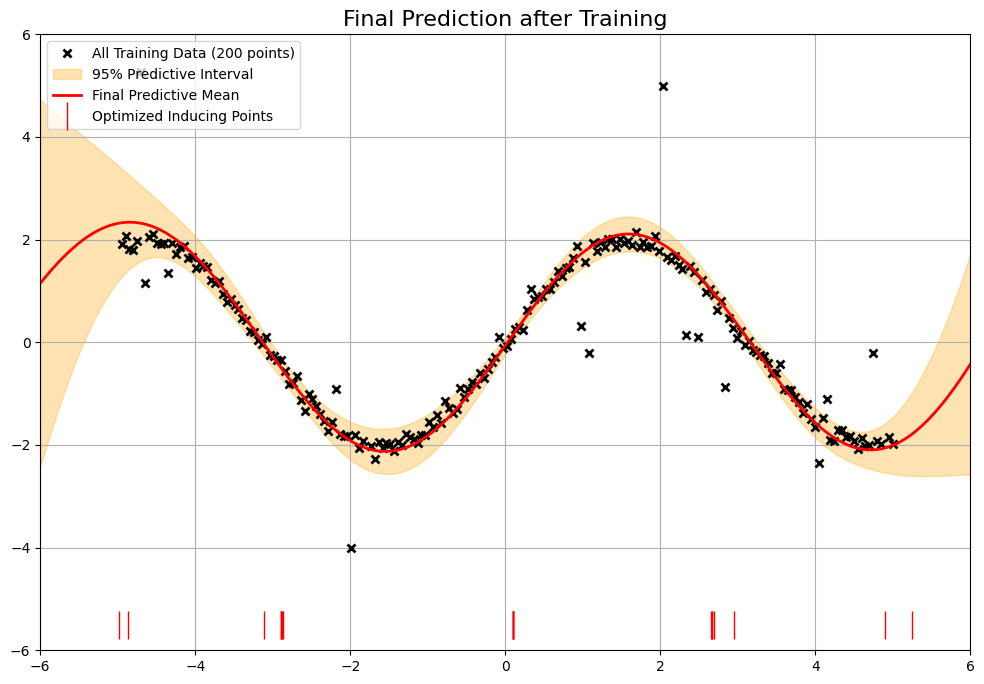

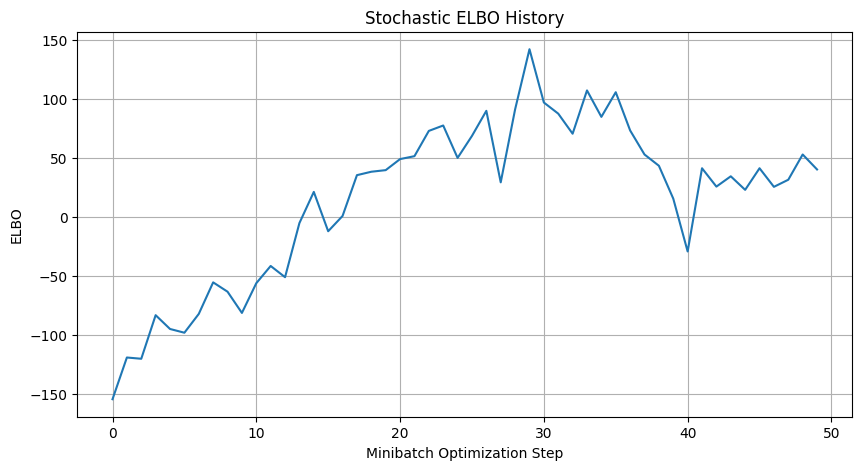

In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class StreamingTPRegression(nn.Module):
    """
    Implements a streaming/online version of the TP Regression model.

    This version includes online optimization of hyperparameters and inducing points (Z)
    using a nested optimization loop within the main `fit` method.
    """
    def __init__(self, M, D, N_total, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.M = M
        self.D = D
        self.N_total = N_total # Total size of the dataset for scaling the ELBO

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        self.Z = nn.Parameter(Z_initial.clone())
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.nu_f = torch.tensor(nu_f)
        self.nu_e = torch.tensor(nu_e)

        # --- Global Variational Parameters ---
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M) # Cholesky of covariance S_u
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        return lengthscale, variance, sigma_sq

    def kernel(self, A, B):
        """ RBF kernel, uses current hyperparameter values. """
        lengthscale, variance, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def partial_fit(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Performs the E-Step for a minibatch: updates the variational posterior q(u), q(r)
        and infers local q(lambda_i) for the batch.
        This method should be called within a `torch.no_grad()` context.
        """
        N_batch = X_batch.shape[0]
        _, _, sigma_sq = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(X_batch, self.Z)
        Kxx_diag_batch = self.kernel(X_batch, X_batch).diag()

        alpha_lambda_batch = torch.ones(N_batch, 1)
        beta_lambda_batch = torch.ones(N_batch, 1)

        for _ in range(cavi_max_iter):
            alpha_lambda_old = alpha_lambda_batch.clone()
            
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f_batch = Kxz_batch @ Kzz_inv_mu
            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
            A_batch = torch.linalg.solve(Kzz, Kxz_batch.T).T
            var_f_inducing = torch.sum((A_batch @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag_batch - torch.sum(A_batch * Kxz_batch, dim=1))
            Var_q_f_batch = (var_f_prior + var_f_inducing).unsqueeze(1)
            
            alpha_lambda_batch = self.nu_e / 2.0 + 0.5
            expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
            beta_lambda_batch = self.nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

            if torch.norm(alpha_lambda_batch - alpha_lambda_old) < cavi_tol:
                break
        
        E_lambda_batch = alpha_lambda_batch / beta_lambda_batch
        
        P_u_inv_S_u = torch.cholesky_solve(self.L_u @ self.L_u.T, Lzz)
        m_u_term = self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(P_u_inv_S_u) + m_u_term
        
        self.alpha_r = self.nu_f / 2.0 + self.M / 2.0
        self.beta_r = self.nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()
        
        E_r = self.alpha_r / self.beta_r
        P_u = E_r * torch.inverse(Kzz) + A_batch.T @ (E_lambda_batch * A_batch) / sigma_sq
        h_u = (A_batch.T * E_lambda_batch.T) @ y_batch / sigma_sq
        
        L_P = torch.linalg.cholesky(P_u + torch.eye(self.M) * 1e-6)
        S_u = torch.cholesky_solve(torch.eye(self.M), L_P)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)
        self.m_u = S_u @ h_u

        return alpha_lambda_batch, beta_lambda_batch

    def _calculate_stochastic_elbo(self, X_batch, y_batch, local_params):
        """
        Calculates the stochastic ELBO for the current minibatch.
        """
        alpha_lambda_batch, beta_lambda_batch = local_params
        N_batch = X_batch.shape[0]
        
        lengthscale, variance, sigma_sq = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(X_batch, self.Z)
        Kxx_diag = self.kernel(X_batch, X_batch).diag()

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (y_batch - E_q_f).pow(2) + Var_q_f

        E_lambda = alpha_lambda_batch / beta_lambda_batch
        E_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)

        e_log_lik = -0.5 * N_batch * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * N_batch * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)
        
        scaled_e_log_lik = e_log_lik * (self.N_total / N_batch)

        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (self.nu_f / 2) * torch.log(self.nu_f / 2) - torch.lgamma(self.nu_f / 2) + \
                  (self.nu_f / 2 - 1) * E_log_r - (self.nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        kl_lambda = torch.lgamma(alpha_lambda_batch) - alpha_lambda_batch * torch.log(beta_lambda_batch) - \
                    (torch.lgamma(self.nu_e / 2) - (self.nu_e / 2) * torch.log(self.nu_e / 2)) - \
                    (alpha_lambda_batch - self.nu_e / 2) * E_log_lambda + \
                    (beta_lambda_batch - self.nu_e / 2) * E_lambda
        
        scaled_kl_lambda = torch.sum(kl_lambda) * (self.N_total / N_batch)

        elbo = scaled_e_log_lik - kl_u_r - scaled_kl_lambda
        return elbo

    def fit(self, X_full, y_full, num_epochs=5, batch_size=20, lr=0.01, inner_loop_max_iter=5):
        """
        Orchestrates the training process with a nested loop structure.
        For each minibatch, it iterates E-M steps to better maximize the ELBO.
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        num_batches = X_full.shape[0] // batch_size
        elbo_history = []
        total_iterations = 0

        print(f"Starting training for {num_epochs} epochs...")
        for epoch in range(num_epochs):
            # Shuffle data at the beginning of each epoch
            permutation = torch.randperm(X_full.size(0))
            
            pbar = tqdm.trange(num_batches)
            pbar.set_description(f"Epoch {epoch+1}/{num_epochs}")

            for i in pbar:
                indices = permutation[i * batch_size : (i + 1) * batch_size]
                X_batch, y_batch = X_full[indices], y_full[indices]

                # --- Inner loop to maximize ELBO for the current minibatch ---
                for _ in range(inner_loop_max_iter):
                    # E-Step: Update variational params for the batch
                    with torch.no_grad():
                        local_params = self.partial_fit(X_batch, y_batch)

                    # M-Step: Update hyperparameters and Z based on the batch ELBO
                    optimizer.zero_grad()
                    neg_elbo = -self._calculate_stochastic_elbo(X_batch, y_batch, local_params)
                    neg_elbo.backward()
                    optimizer.step()
                
                elbo_history.append(-neg_elbo.item())
                pbar.set_postfix(ELBO=f"{-neg_elbo.item():.2f}")
                total_iterations += 1
        
        return elbo_history


    def predict(self, X_test):
        """ Makes predictions at new points X_test using the current global posterior. """
        with torch.no_grad():
            Z_final = self.Z
            m_u_final = self.m_u
            L_u_final = self.L_u
            
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            Kzz_inv_mu = torch.cholesky_solve(m_u_final, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ L_u_final)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            pred_nu = 2 * self.alpha_r

            return pred_mean, pred_var.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # 1. Generate data
    N_total = 200
    X_full = torch.linspace(-5, 5, N_total).unsqueeze(1)
    y_true = torch.sin(X_full) * 2
    noise = torch.randn(N_total, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N_total, 1)) * 0.5
    y_full = y_true + noise
    outlier_indices = torch.randperm(N_total)[:20]
    y_full[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_full[60] = -4.0
    y_full[140] = 5.0

    # 2. Setup the streaming model
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = StreamingTPRegression(
        M=M,
        D=1,
        N_total=N_total,
        Z_initial=Z_initial,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model using the new fit method with the inner loop
    elbo_history = model.fit(X_full, y_full, num_epochs=5, batch_size=20, lr=0.01, inner_loop_max_iter=10)

    print("\n--- Finished Training ---")
    
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")
    print("\n--- Final Hyperparameters ---")
    lengthscale, variance, sigma_sq = model._get_hyperparams()
    print(f"Lengthscale: {lengthscale.item():.4f}")
    print(f"Variance: {variance.item():.4f}")
    print(f"Likelihood Sigma^2: {sigma_sq.item():.4f}")
    print(f"Degrees of Freedom (nu_f): {model.nu_f.item():.4f}")
    print(f"Degrees of Freedom (nu_e): {model.nu_e.item():.4f}")

    # 4. Visualize the final result
    plt.figure(figsize=(12, 8))
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean_final, pred_var_final, pred_nu_final = model.predict(X_test)
    pred_scale_final = torch.sqrt(pred_var_final)
    df_final = pred_nu_final.item()
    lower_final = pred_mean_final + t.ppf(0.025, df=df_final) * pred_scale_final
    upper_final = pred_mean_final + t.ppf(0.975, df=df_final) * pred_scale_final

    plt.plot(X_full, y_full, 'kx', mew=2, label=f'All Training Data ({N_total} points)')
    plt.fill_between(X_test.squeeze(), lower_final.squeeze(), upper_final.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean_final, 'r-', lw=2, label='Final Predictive Mean')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')
    plt.title(f'Final Prediction after Training', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

    # Plot ELBO history
    plt.figure(figsize=(10, 5))
    plt.plot(elbo_history)
    plt.title("Stochastic ELBO History")
    plt.xlabel("Minibatch Optimization Step")
    plt.ylabel("ELBO")
    plt.grid(True)
    plt.show()


Starting training for 5 epochs...


Epoch 1/5:   0%|          | 0/4 [00:00<?, ?it/s, ELBO=-176.80]

Epoch 5/5: 100%|██████████| 4/4 [00:00<00:00, 40.52it/s, ELBO=-148.48]



--- Finished Training ---

--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-5.35915239 -5.06066793 -4.04108774 -3.33573855 -3.20615443 -2.45959382
 -1.93690323 -1.32113246 -0.53899967 -0.44130494  0.48864322  0.46250602
  1.28416795  1.96696547  2.934486    2.58420261  3.51755865  4.11236379
  4.98689027  5.17510097]
-------------------

--- Final Hyperparameters ---
Lengthscale: 1.1869
Variance: 0.8011
Likelihood Sigma^2: 0.2001
Degrees of Freedom (nu_f): 2.1391
Degrees of Freedom (nu_e): 2.0777


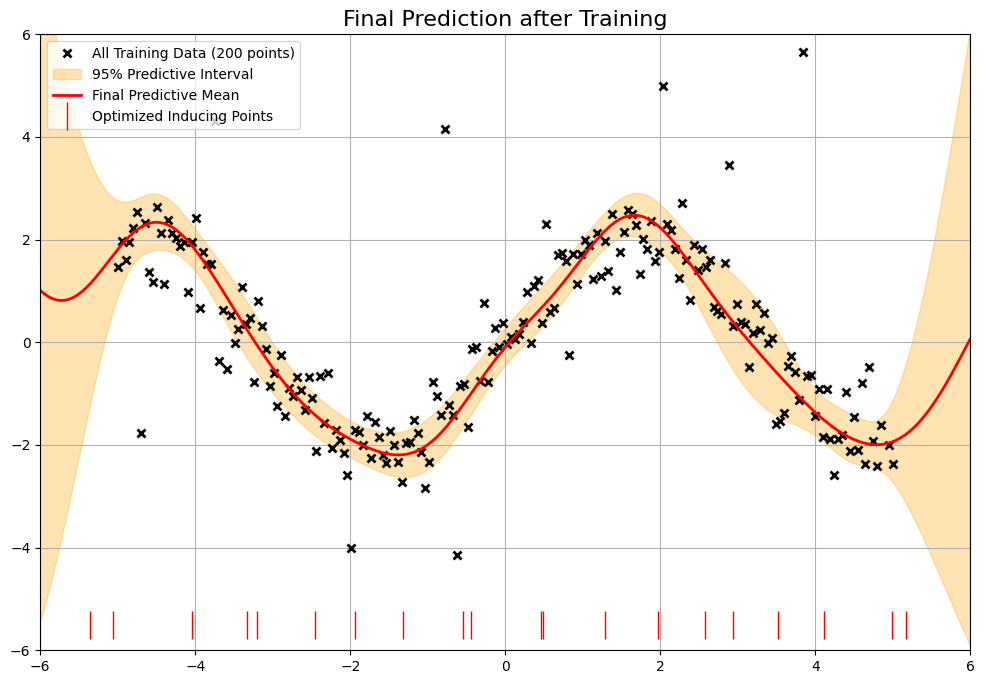

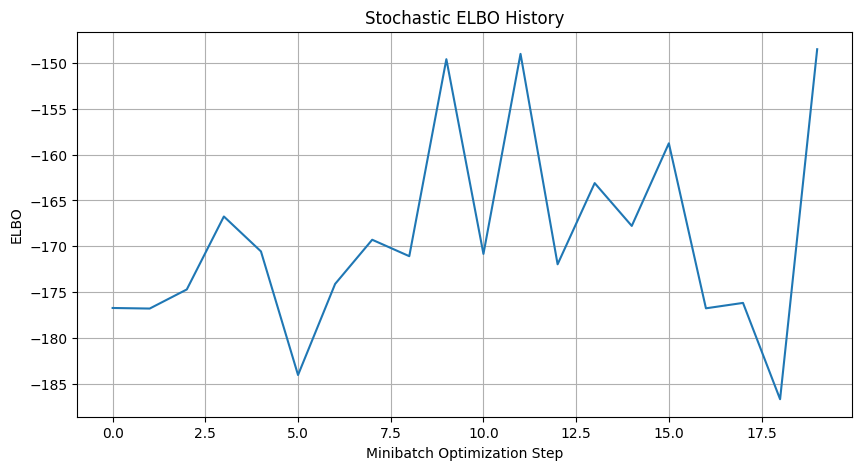

In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class StreamingTPRegression(nn.Module):
    """
    Implements a streaming/online version of the TP Regression model.

    This version includes online optimization of all hyperparameters (kernel, noise, DoF)
    and inducing points (Z) using a nested optimization loop within the main `fit` method.
    """
    def __init__(self, M, D, N_total, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.M = M
        self.D = D
        self.N_total = N_total # Total size of the dataset for scaling the ELBO

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        self.Z = nn.Parameter(Z_initial.clone())
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        
        # Parameterize log(nu - 2) to ensure nu > 2, which is required for variance to be defined.
        self.log_nu_f_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_f - 2.0)))
        self.log_nu_e_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_e - 2.0)))


        # --- Global Variational Parameters ---
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M) # Cholesky of covariance S_u
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        
        # Ensure nu > 2 by parameterizing nu = 2 + exp(log(nu-2))
        nu_f = 2.0 + torch.exp(self.log_nu_f_minus_2)
        nu_e = 2.0 + torch.exp(self.log_nu_e_minus_2)

        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """ RBF kernel, uses current hyperparameter values. """
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def partial_fit(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Performs the E-Step for a minibatch: updates the variational posterior q(u), q(r)
        and infers local q(lambda_i) for the batch.
        This method should be called within a `torch.no_grad()` context.
        """
        N_batch = X_batch.shape[0]
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(X_batch, self.Z)
        Kxx_diag_batch = self.kernel(X_batch, X_batch).diag()

        alpha_lambda_batch = torch.ones(N_batch, 1)
        beta_lambda_batch = torch.ones(N_batch, 1)

        for _ in range(cavi_max_iter):
            alpha_lambda_old = alpha_lambda_batch.clone()
            
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f_batch = Kxz_batch @ Kzz_inv_mu
            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
            A_batch = torch.linalg.solve(Kzz, Kxz_batch.T).T
            var_f_inducing = torch.sum((A_batch @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag_batch - torch.sum(A_batch * Kxz_batch, dim=1))
            Var_q_f_batch = (var_f_prior + var_f_inducing).unsqueeze(1)
            
            # Update local q(lambda) using current nu_e
            alpha_lambda_batch = nu_e / 2.0 + 0.5
            expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
            beta_lambda_batch = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

            if torch.norm(alpha_lambda_batch - alpha_lambda_old) < cavi_tol:
                break
        
        E_lambda_batch = alpha_lambda_batch / beta_lambda_batch
        
        P_u_inv_S_u = torch.cholesky_solve(self.L_u @ self.L_u.T, Lzz)
        m_u_term = self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(P_u_inv_S_u) + m_u_term
        
        # Update for q(r) using current nu_f
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()
        
        E_r = self.alpha_r / self.beta_r
        P_u = E_r * torch.inverse(Kzz) + A_batch.T @ (E_lambda_batch * A_batch) / sigma_sq
        h_u = (A_batch.T * E_lambda_batch.T) @ y_batch / sigma_sq
        
        L_P = torch.linalg.cholesky(P_u + torch.eye(self.M) * 1e-6)
        S_u = torch.cholesky_solve(torch.eye(self.M), L_P)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)
        self.m_u = S_u @ h_u

        return alpha_lambda_batch, beta_lambda_batch

    def _calculate_stochastic_elbo(self, X_batch, y_batch, local_params):
        """
        Calculates the stochastic ELBO for the current minibatch.
        """
        alpha_lambda_batch, beta_lambda_batch = local_params
        N_batch = X_batch.shape[0]
        
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(X_batch, self.Z)
        Kxx_diag = self.kernel(X_batch, X_batch).diag()

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (y_batch - E_q_f).pow(2) + Var_q_f

        E_lambda = alpha_lambda_batch / beta_lambda_batch
        E_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)

        e_log_lik = -0.5 * N_batch * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * N_batch * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)
        
        scaled_e_log_lik = e_log_lik * (self.N_total / N_batch)

        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        # log_p_r now depends on the optimizable nu_f
        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # kl_lambda now depends on the optimizable nu_e
        kl_lambda = torch.lgamma(alpha_lambda_batch) - alpha_lambda_batch * torch.log(beta_lambda_batch) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (alpha_lambda_batch - nu_e / 2) * E_log_lambda + \
                    (beta_lambda_batch - nu_e / 2) * E_lambda
        
        scaled_kl_lambda = torch.sum(kl_lambda) * (self.N_total / N_batch)

        elbo = scaled_e_log_lik - kl_u_r - scaled_kl_lambda
        return elbo

    def fit(self, X_full, y_full, num_epochs=5, batch_size=20, lr=0.01, inner_loop_max_iter=5):
        """
        Orchestrates the training process with a nested loop structure.
        For each minibatch, it iterates E-M steps to better maximize the ELBO.
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        num_batches = X_full.shape[0] // batch_size
        elbo_history = []
        total_iterations = 0

        print(f"Starting training for {num_epochs} epochs...")
        for epoch in range(num_epochs):
            permutation = torch.randperm(X_full.size(0))
            
            pbar = tqdm.trange(num_batches)
            pbar.set_description(f"Epoch {epoch+1}/{num_epochs}")

            for i in pbar:
                indices = permutation[i * batch_size : (i + 1) * batch_size]
                X_batch, y_batch = X_full[indices], y_full[indices]

                for _ in range(inner_loop_max_iter):
                    with torch.no_grad():
                        local_params = self.partial_fit(X_batch, y_batch)

                    optimizer.zero_grad()
                    neg_elbo = -self._calculate_stochastic_elbo(X_batch, y_batch, local_params)
                    neg_elbo.backward()
                    optimizer.step()
                
                elbo_history.append(-neg_elbo.item())
                pbar.set_postfix(ELBO=f"{-neg_elbo.item():.2f}")
                total_iterations += 1
        
        return elbo_history


    def predict(self, X_test):
        """ Makes predictions at new points X_test using the current global posterior. """
        with torch.no_grad():
            Z_final = self.Z
            m_u_final = self.m_u
            L_u_final = self.L_u
            
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            Kzz_inv_mu = torch.cholesky_solve(m_u_final, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ L_u_final)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            # The predictive degrees of freedom also depends on the learned nu_f
            _, _, _, nu_f, _ = self._get_hyperparams()
            pred_nu = 2 * (nu_f / 2.0 + self.M / 2.0) # This is 2 * alpha_r

            return pred_mean, pred_var.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # 1. Generate data
    N_total = 200
    X_full = torch.linspace(-5, 5, N_total).unsqueeze(1)
    y_true = torch.sin(X_full) * 2
    noise = torch.randn(N_total, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N_total, 1)) * 0.5
    y_full = y_true + noise
    outlier_indices = torch.randperm(N_total)[:20]
    y_full[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_full[60] = -4.0
    y_full[140] = 5.0

    # 2. Setup the streaming model
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = StreamingTPRegression(
        M=M,
        D=1,
        N_total=N_total,
        Z_initial=Z_initial,
        # Initialize nu > 2
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model using the new fit method with the inner loop
    elbo_history = model.fit(X_full, y_full, num_epochs=5, batch_size=50, lr=0.01, inner_loop_max_iter=5)

    print("\n--- Finished Training ---")
    
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")
    print("\n--- Final Hyperparameters ---")
    lengthscale, variance, sigma_sq, nu_f, nu_e = model._get_hyperparams()
    print(f"Lengthscale: {lengthscale.item():.4f}")
    print(f"Variance: {variance.item():.4f}")
    print(f"Likelihood Sigma^2: {sigma_sq.item():.4f}")
    print(f"Degrees of Freedom (nu_f): {nu_f.item():.4f}")
    print(f"Degrees of Freedom (nu_e): {nu_e.item():.4f}")


    # 4. Visualize the final result
    plt.figure(figsize=(12, 8))
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean_final, pred_var_final, pred_nu_final = model.predict(X_test)
    pred_scale_final = torch.sqrt(pred_var_final)
    df_final = pred_nu_final.item()
    lower_final = pred_mean_final + t.ppf(0.025, df=df_final) * pred_scale_final
    upper_final = pred_mean_final + t.ppf(0.975, df=df_final) * pred_scale_final

    plt.plot(X_full, y_full, 'kx', mew=2, label=f'All Training Data ({N_total} points)')
    plt.fill_between(X_test.squeeze(), lower_final.squeeze(), upper_final.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean_final, 'r-', lw=2, label='Final Predictive Mean')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')
    plt.title(f'Final Prediction after Training', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

    # Plot ELBO history
    plt.figure(figsize=(10, 5))
    plt.plot(elbo_history)
    plt.title("Stochastic ELBO History")
    plt.xlabel("Minibatch Optimization Step")
    plt.ylabel("ELBO")
    plt.grid(True)
    plt.show()


Starting training for up to 50 epochs with patience=5...


Epoch 1/50: 100%|██████████| 8/8 [00:00<00:00, 31.85it/s, Train_ELBO=-82.31, Val_ELBO=-inf] 



Epoch 1: Validation ELBO = -50.9666
  -> New best validation ELBO. Saving model state.


Epoch 2/50: 100%|██████████| 8/8 [00:00<00:00, 33.35it/s, Train_ELBO=-45.90, Val_ELBO=-50.97]



Epoch 2: Validation ELBO = -42.0433
  -> New best validation ELBO. Saving model state.


...


Epoch 10: Validation ELBO = -28.0843
  -> Validation ELBO did not improve. Patience: 3/5


Epoch 11/50: 100%|██████████| 8/8 [00:00<00:00, 33.53it/s, Train_ELBO=46.57, Val_ELBO=-15.01]



Epoch 11: Validation ELBO = -24.1270
  -> Validation ELBO did not improve. Patience: 4/5


Epoch 12/50: 100%|██████████| 8/8 [00:00<00:00, 34.19it/s, Train_ELBO=10.56, Val_ELBO=-15.01]



Epoch 12: Validation ELBO = -26.0551
  -> Validation ELBO did not improve. Patience: 5/5

Stopping early after 12 epochs.
Restoring model to best validation state.

--- Finished Training ---

--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-5.43257543 -5.4392382  -5.2416957  -2.77876232 -2.77816326 -2.7665694
 -2.85464668 -1.3841178  -0.68945223  0.12621353  0.23297911  0.64096327
  0.70976486  2.78679223  2.74507965  2.74809577  2.74836864  5.44512943
  5.1173315   5.18741497]
-------------------

--- Final Hyperparameters (from best validation epoch) ---
Lengthscale: 3.0633
Variance: 0.1838
Likelihood Sigma^2: 0.0240
Degrees of Freedom (nu_f): 2.0250
Degrees of Freedom (nu_e): 2.0807


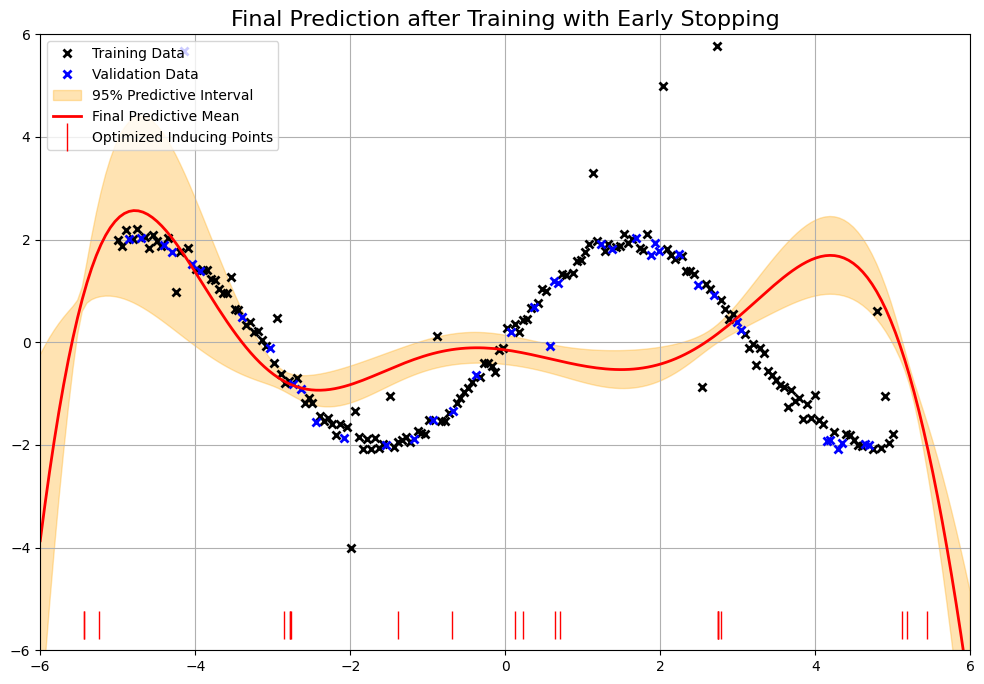

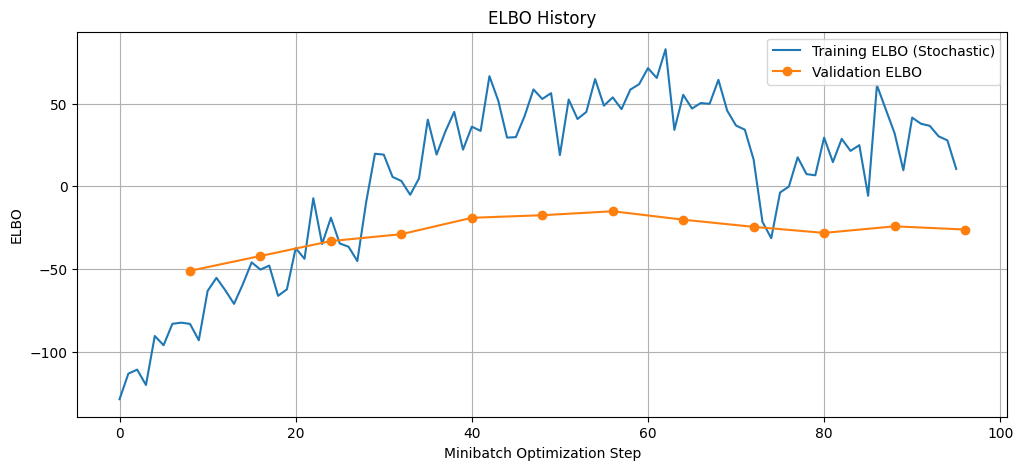

In [21]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm
import copy

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class StreamingTPRegression(nn.Module):
    """
    Implements a streaming/online version of the TP Regression model.

    This version includes online optimization of all hyperparameters (kernel, noise, DoF)
    and inducing points (Z) using a nested optimization loop within the main `fit` method.
    The fit method now includes early stopping based on a validation set.
    """
    def __init__(self, M, D, N_total, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.M = M
        self.D = D
        self.N_total = N_total # Total size of the dataset for scaling the ELBO

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        self.Z = nn.Parameter(Z_initial.clone())
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        
        self.log_nu_f_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_f - 2.0)))
        self.log_nu_e_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_e - 2.0)))


        # --- Global Variational Parameters ---
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M) # Cholesky of covariance S_u
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        
        nu_f = 2.0 + torch.exp(self.log_nu_f_minus_2)
        nu_e = 2.0 + torch.exp(self.log_nu_e_minus_2)

        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """ RBF kernel, uses current hyperparameter values. """
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def partial_fit(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Performs the E-Step for a minibatch: updates the variational posterior q(u), q(r)
        and infers local q(lambda_i) for the batch.
        This method should be called within a `torch.no_grad()` context.
        """
        N_batch = X_batch.shape[0]
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(X_batch, self.Z)
        Kxx_diag_batch = self.kernel(X_batch, X_batch).diag()

        alpha_lambda_batch = torch.ones(N_batch, 1)
        beta_lambda_batch = torch.ones(N_batch, 1)

        for _ in range(cavi_max_iter):
            alpha_lambda_old = alpha_lambda_batch.clone()
            
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f_batch = Kxz_batch @ Kzz_inv_mu
            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
            A_batch = torch.linalg.solve(Kzz, Kxz_batch.T).T
            var_f_inducing = torch.sum((A_batch @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag_batch - torch.sum(A_batch * Kxz_batch, dim=1))
            Var_q_f_batch = (var_f_prior + var_f_inducing).unsqueeze(1)
            
            alpha_lambda_batch = nu_e / 2.0 + 0.5
            expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
            beta_lambda_batch = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

            if torch.norm(alpha_lambda_batch - alpha_lambda_old) < cavi_tol:
                break
        
        E_lambda_batch = alpha_lambda_batch / beta_lambda_batch
        
        P_u_inv_S_u = torch.cholesky_solve(self.L_u @ self.L_u.T, Lzz)
        m_u_term = self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(P_u_inv_S_u) + m_u_term
        
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()
        
        E_r = self.alpha_r / self.beta_r
        P_u = E_r * torch.inverse(Kzz) + A_batch.T @ (E_lambda_batch * A_batch) / sigma_sq
        h_u = (A_batch.T * E_lambda_batch.T) @ y_batch / sigma_sq
        
        L_P = torch.linalg.cholesky(P_u + torch.eye(self.M) * 1e-6)
        S_u = torch.cholesky_solve(torch.eye(self.M), L_P)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)
        self.m_u = S_u @ h_u

        return alpha_lambda_batch, beta_lambda_batch

    def _calculate_stochastic_elbo(self, X_batch, y_batch, local_params):
        """
        Calculates the stochastic ELBO for the current minibatch.
        """
        alpha_lambda_batch, beta_lambda_batch = local_params
        N_batch = X_batch.shape[0]
        
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(X_batch, self.Z)
        Kxx_diag = self.kernel(X_batch, X_batch).diag()

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (y_batch - E_q_f).pow(2) + Var_q_f

        E_lambda = alpha_lambda_batch / beta_lambda_batch
        E_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)

        e_log_lik = -0.5 * N_batch * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * N_batch * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)
        
        scaled_e_log_lik = e_log_lik * (self.N_total / N_batch)

        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        kl_lambda = torch.lgamma(alpha_lambda_batch) - alpha_lambda_batch * torch.log(beta_lambda_batch) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (alpha_lambda_batch - nu_e / 2) * E_log_lambda + \
                    (beta_lambda_batch - nu_e / 2) * E_lambda
        
        scaled_kl_lambda = torch.sum(kl_lambda) * (self.N_total / N_batch)

        elbo = scaled_e_log_lik - kl_u_r - scaled_kl_lambda
        return elbo

    def evaluate_elbo(self, X_data, y_data):
        """
        Calculates the ELBO for a given dataset without performing updates.
        Used for validation.
        """
        with torch.no_grad():
            temp_model = copy.deepcopy(self)
            local_params = temp_model.partial_fit(X_data, y_data)
            
            alpha_lambda_data, beta_lambda_data = local_params
            N_data = X_data.shape[0]
            
            lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

            Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)
            Kxz = self.kernel(X_data, self.Z)
            Kxx_diag = self.kernel(X_data, X_data).diag()

            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu
            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)
            expected_sq_error = (y_data - E_q_f).pow(2) + Var_q_f
            E_lambda = alpha_lambda_data / beta_lambda_data
            E_log_lambda = torch.digamma(alpha_lambda_data) - torch.log(beta_lambda_data)
            e_log_lik = -0.5 * N_data * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * N_data * torch.log(sigma_sq) + \
                        0.5 * torch.sum(E_log_lambda) - \
                        0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

            S_u = self.L_u @ self.L_u.T
            E_r = self.alpha_r / self.beta_r
            E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
            log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
            log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + (self.alpha_r - 1) * E_log_r - self.beta_r * E_r
            E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
            log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + 0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u
            log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r
            kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

            kl_lambda = torch.lgamma(alpha_lambda_data) - alpha_lambda_data * torch.log(beta_lambda_data) - \
                        (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                        (alpha_lambda_data - nu_e / 2) * E_log_lambda + \
                        (beta_lambda_data - nu_e / 2) * E_lambda
            
            kl_lambda_sum = torch.sum(kl_lambda)

            elbo = e_log_lik - kl_u_r - kl_lambda_sum
            return elbo


    def fit(self, X_train, y_train, X_val, y_val, num_epochs=50, batch_size=20, lr=0.01, inner_loop_max_iter=5, patience=5):
        """
        Orchestrates the training process with early stopping.
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        num_batches = X_train.shape[0] // batch_size
        train_elbo_history = []
        val_elbo_history = []
        
        best_val_elbo = -torch.inf
        patience_counter = 0
        best_model_state = None

        print(f"Starting training for up to {num_epochs} epochs with patience={patience}...")
        for epoch in range(num_epochs):
            permutation = torch.randperm(X_train.size(0))
            
            pbar = tqdm.trange(num_batches)
            pbar.set_description(f"Epoch {epoch+1}/{num_epochs}")

            for i in pbar:
                indices = permutation[i * batch_size : (i + 1) * batch_size]
                X_batch, y_batch = X_train[indices], y_train[indices]

                for _ in range(inner_loop_max_iter):
                    with torch.no_grad():
                        local_params = self.partial_fit(X_batch, y_batch)

                    optimizer.zero_grad()
                    neg_elbo = -self._calculate_stochastic_elbo(X_batch, y_batch, local_params)
                    neg_elbo.backward()
                    optimizer.step()
                
                train_elbo_history.append(-neg_elbo.item())
                # FIX: Use .item() on best_val_elbo if it's a tensor
                current_best_val = best_val_elbo if isinstance(best_val_elbo, float) else best_val_elbo.item()
                pbar.set_postfix(Train_ELBO=f"{-neg_elbo.item():.2f}", Val_ELBO=f"{current_best_val:.2f}")

            # --- Early Stopping Check ---
            val_elbo = self.evaluate_elbo(X_val, y_val)
            val_elbo_history.append(val_elbo.item())
            print(f"\nEpoch {epoch+1}: Validation ELBO = {val_elbo.item():.4f}")

            if val_elbo.item() > best_val_elbo:
                best_val_elbo = val_elbo.item()
                patience_counter = 0
                best_model_state = copy.deepcopy(self.state_dict())
                print(f"  -> New best validation ELBO. Saving model state.")
            else:
                patience_counter += 1
                print(f"  -> Validation ELBO did not improve. Patience: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print(f"\nStopping early after {epoch+1} epochs.")
                break
        
        if best_model_state is not None:
            print("Restoring model to best validation state.")
            self.load_state_dict(best_model_state)
            
        return train_elbo_history, val_elbo_history


    def predict(self, X_test):
        """ Makes predictions at new points X_test using the current global posterior. """
        with torch.no_grad():
            Z_final = self.Z
            m_u_final = self.m_u
            L_u_final = self.L_u
            
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            Kzz_inv_mu = torch.cholesky_solve(m_u_final, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ L_u_final)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            _, _, _, nu_f, _ = self._get_hyperparams()
            pred_nu = 2 * (nu_f / 2.0 + self.M / 2.0)

            return pred_mean, pred_var.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # 1. Generate data
    N_total = 200
    X_full = torch.linspace(-5, 5, N_total).unsqueeze(1)
    y_true = torch.sin(X_full) * 2
    noise = torch.randn(N_total, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N_total, 1)) * 0.5
    y_full = y_true + noise
    outlier_indices = torch.randperm(N_total)[:20]
    y_full[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_full[60] = -4.0
    y_full[140] = 5.0

    # 2. Split data into training and validation sets
    val_frac = 0.2
    N_val = int(N_total * val_frac)
    val_indices = torch.randperm(N_total)[:N_val]
    train_indices = torch.tensor(list(set(range(N_total)) - set(val_indices.tolist())))

    X_train, y_train = X_full[train_indices], y_full[train_indices]
    X_val, y_val = X_full[val_indices], y_full[val_indices]
    
    N_train = X_train.shape[0]

    # 3. Setup the streaming model
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)
    batch_size = 20 # Define batch_size here to calculate num_batches

    model = StreamingTPRegression(
        M=M,
        D=1,
        N_total=N_train, # ELBO scaling is based on the size of the training set
        Z_initial=Z_initial,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 4. Fit the model using the new fit method with early stopping
    train_elbo_history, val_elbo_history = model.fit(
        X_train, y_train, X_val, y_val, 
        num_epochs=50, batch_size=batch_size, lr=0.01, 
        inner_loop_max_iter=5, patience=5
    )

    print("\n--- Finished Training ---")
    
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")
    print("\n--- Final Hyperparameters (from best validation epoch) ---")
    lengthscale, variance, sigma_sq, nu_f, nu_e = model._get_hyperparams()
    print(f"Lengthscale: {lengthscale.item():.4f}")
    print(f"Variance: {variance.item():.4f}")
    print(f"Likelihood Sigma^2: {sigma_sq.item():.4f}")
    print(f"Degrees of Freedom (nu_f): {nu_f.item():.4f}")
    print(f"Degrees of Freedom (nu_e): {nu_e.item():.4f}")


    # 5. Visualize the final result
    plt.figure(figsize=(12, 8))
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean_final, pred_var_final, pred_nu_final = model.predict(X_test)
    pred_scale_final = torch.sqrt(pred_var_final)
    df_final = pred_nu_final.item()
    lower_final = pred_mean_final + t.ppf(0.025, df=df_final) * pred_scale_final
    upper_final = pred_mean_final + t.ppf(0.975, df=df_final) * pred_scale_final

    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data')
    plt.plot(X_val, y_val, 'bx', mew=2, label='Validation Data')
    plt.fill_between(X_test.squeeze(), lower_final.squeeze(), upper_final.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean_final, 'r-', lw=2, label='Final Predictive Mean')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')
    plt.title(f'Final Prediction after Training with Early Stopping', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

    # Plot ELBO history
    plt.figure(figsize=(12, 5))
    plt.plot(train_elbo_history, label='Training ELBO (Stochastic)')
    # Plot validation ELBO at the end of each epoch
    num_batches = X_train.shape[0] // batch_size # Define num_batches for plotting
    val_iters = [num_batches * (i+1) for i in range(len(val_elbo_history))]
    plt.plot(val_iters, val_elbo_history, 'o-', label='Validation ELBO')
    plt.title("ELBO History")
    plt.xlabel("Minibatch Optimization Step")
    plt.ylabel("ELBO")
    plt.legend()
    plt.grid(True)
    plt.show()


Starting training for 20 epochs...


Epoch 1/20:   0%|          | 0/4 [00:00<?, ?it/s, ELBO=-170.08]

Epoch 20/20: 100%|██████████| 4/4 [00:00<00:00, 31.86it/s, ELBO=-158.92]



--- Finished Training ---

--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-5.36999448 -5.29739843 -5.29935976 -2.60130383 -2.6025483  -2.60254504
 -2.6001735  -0.46799687 -0.47968264 -0.48443057 -0.48807389 -0.47949766
  0.29757145  1.71374054  3.7441041   3.74864981  3.69991693  3.76868957
  5.34777036  5.34725068]
-------------------

--- Final Hyperparameters ---
Lengthscale: 2.6917
Variance: 0.1188
Likelihood Sigma^2: 0.2008
Degrees of Freedom (nu_f): 2.0131
Degrees of Freedom (nu_e): 2.0853


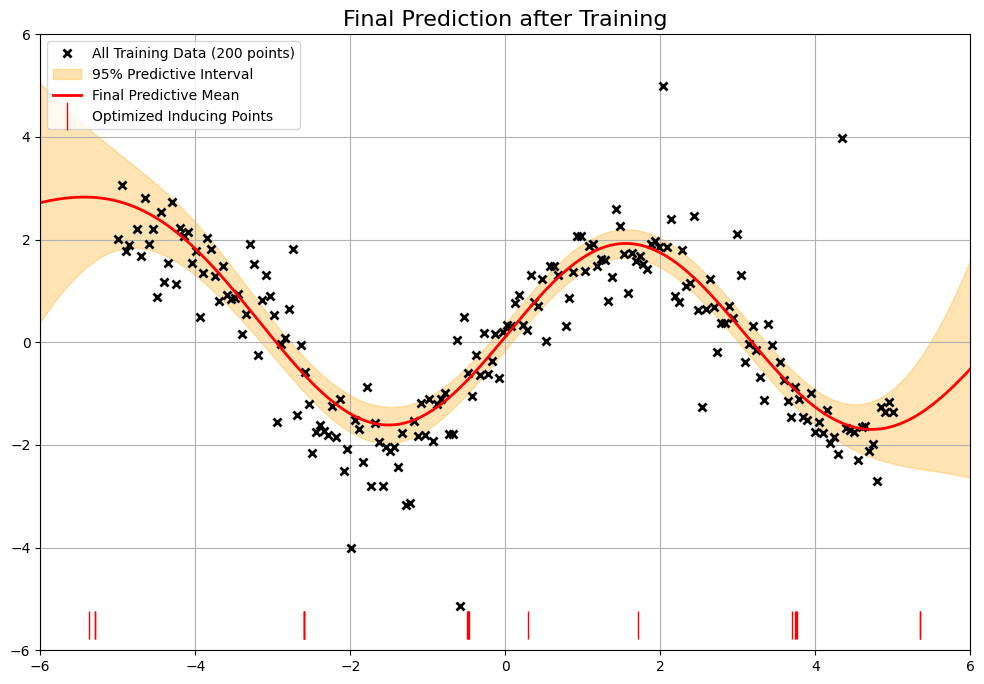

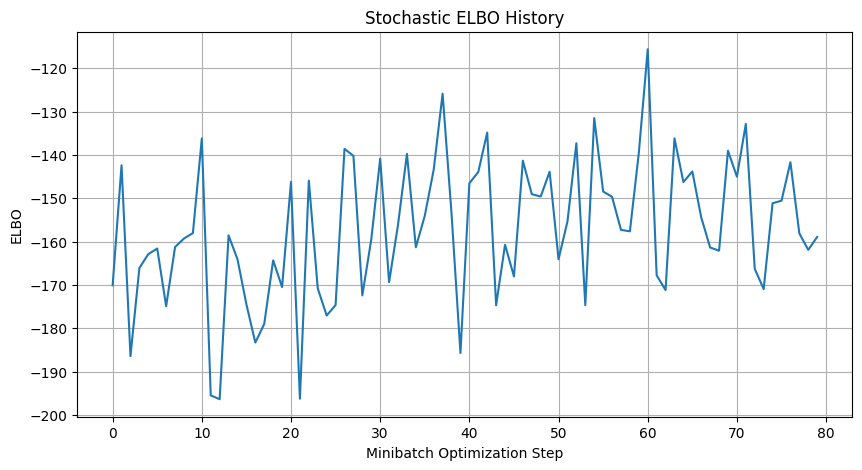

In [27]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class StreamingTPRegression(nn.Module):
    """
    Implements a streaming/online version of the TP Regression model.

    This version includes online optimization of all hyperparameters (kernel, noise, DoF)
    and inducing points (Z) using a nested optimization loop within the main `fit` method.
    """
    def __init__(self, M, D, N_total, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.M = M
        self.D = D
        self.N_total = N_total # Total size of the dataset for scaling the ELBO

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        self.Z = nn.Parameter(Z_initial.clone())
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        
        # Parameterize log(nu - 2) to ensure nu > 2, which is required for variance to be defined.
        self.log_nu_f_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_f - 2.0)))
        self.log_nu_e_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_e - 2.0)))


        # --- Global Variational Parameters ---
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M) # Cholesky of covariance S_u
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters and inducing points from storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        
        # Ensure nu > 2 by parameterizing nu = 2 + exp(log(nu-2))
        nu_f = 2.0 + torch.exp(self.log_nu_f_minus_2)
        nu_e = 2.0 + torch.exp(self.log_nu_e_minus_2)

        return lengthscale, variance, sigma_sq, nu_f, nu_e, self.Z

    def kernel(self, A, B):
        """ RBF kernel, uses current hyperparameter values. """
        lengthscale, variance, _, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def partial_fit(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Performs the E-Step for a minibatch: updates the variational posterior q(u), q(r)
        and infers local q(lambda_i) for the batch.
        This method should be called within a `torch.no_grad()` context.
        """
        N_batch = X_batch.shape[0]
        _, _, sigma_sq, nu_f, nu_e, Z = self._get_hyperparams()

        Kzz = self.kernel(Z, Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(X_batch, Z)
        Kxx_diag_batch = self.kernel(X_batch, X_batch).diag()

        alpha_lambda_batch = torch.ones(N_batch, 1)
        beta_lambda_batch = torch.ones(N_batch, 1)

        for _ in range(cavi_max_iter):
            alpha_lambda_old = alpha_lambda_batch.clone()
            
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f_batch = Kxz_batch @ Kzz_inv_mu
            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
            A_batch = torch.linalg.solve(Kzz, Kxz_batch.T).T
            var_f_inducing = torch.sum((A_batch @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag_batch - torch.sum(A_batch * Kxz_batch, dim=1))
            Var_q_f_batch = (var_f_prior + var_f_inducing).unsqueeze(1)
            
            # Update local q(lambda) using current nu_e
            alpha_lambda_batch = nu_e / 2.0 + 0.5
            expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
            beta_lambda_batch = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

            if torch.norm(alpha_lambda_batch - alpha_lambda_old) < cavi_tol:
                break
        
        E_lambda_batch = alpha_lambda_batch / beta_lambda_batch
        
        P_u_inv_S_u = torch.cholesky_solve(self.L_u @ self.L_u.T, Lzz)
        m_u_term = self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(P_u_inv_S_u) + m_u_term
        
        # Update for q(r) using current nu_f
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()
        
        E_r = self.alpha_r / self.beta_r
        P_u = E_r * torch.inverse(Kzz) + A_batch.T @ (E_lambda_batch * A_batch) / sigma_sq
        h_u = (A_batch.T * E_lambda_batch.T) @ y_batch / sigma_sq
        
        L_P = torch.linalg.cholesky(P_u + torch.eye(self.M) * 1e-6)
        S_u = torch.cholesky_solve(torch.eye(self.M), L_P)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)
        self.m_u = S_u @ h_u

        return alpha_lambda_batch, beta_lambda_batch

    def _calculate_stochastic_elbo(self, X_batch, y_batch, local_params):
        """
        Calculates the stochastic ELBO for the current minibatch.
        """
        alpha_lambda_batch, beta_lambda_batch = local_params
        N_batch = X_batch.shape[0]
        
        lengthscale, variance, sigma_sq, nu_f, nu_e, Z = self._get_hyperparams()

        Kzz = self.kernel(Z, Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(X_batch, Z)
        Kxx_diag = self.kernel(X_batch, X_batch).diag()

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (y_batch - E_q_f).pow(2) + Var_q_f

        E_lambda = alpha_lambda_batch / beta_lambda_batch
        E_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)

        e_log_lik = -0.5 * N_batch * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * N_batch * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)
        
        scaled_e_log_lik = e_log_lik * (self.N_total / N_batch)

        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        # log_p_r now depends on the optimizable nu_f
        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # kl_lambda now depends on the optimizable nu_e
        kl_lambda = torch.lgamma(alpha_lambda_batch) - alpha_lambda_batch * torch.log(beta_lambda_batch) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (alpha_lambda_batch - nu_e / 2) * E_log_lambda + \
                    (beta_lambda_batch - nu_e / 2) * E_lambda
        
        scaled_kl_lambda = torch.sum(kl_lambda) * (self.N_total / N_batch)

        elbo = scaled_e_log_lik - kl_u_r - scaled_kl_lambda
        return elbo

    def fit(self, X_full, y_full, num_epochs=5, batch_size=20, lr=0.01, inner_loop_max_iter=5):
        """
        Orchestrates the training process with a nested loop structure.
        For each minibatch, it iterates E-M steps to better maximize the ELBO.
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        num_batches = X_full.shape[0] // batch_size
        elbo_history = []
        total_iterations = 0

        print(f"Starting training for {num_epochs} epochs...")
        for epoch in range(num_epochs):
            permutation = torch.randperm(X_full.size(0))
            
            pbar = tqdm.trange(num_batches)
            pbar.set_description(f"Epoch {epoch+1}/{num_epochs}")

            for i in pbar:
                indices = permutation[i * batch_size : (i + 1) * batch_size]
                X_batch, y_batch = X_full[indices], y_full[indices]

                for _ in range(inner_loop_max_iter):
                    with torch.no_grad():
                        local_params = self.partial_fit(X_batch, y_batch)

                    optimizer.zero_grad()
                    neg_elbo = -self._calculate_stochastic_elbo(X_batch, y_batch, local_params)
                    neg_elbo.backward()
                    optimizer.step()
                
                elbo_history.append(-neg_elbo.item())
                pbar.set_postfix(ELBO=f"{-neg_elbo.item():.2f}")
                total_iterations += 1
        
        return elbo_history


    def predict(self, X_test):
        """ Makes predictions at new points X_test using the current global posterior. """
        with torch.no_grad():
            m_u_final = self.m_u
            L_u_final = self.L_u
            
            # Get hyperparameters and Z in one call
            _, _, _, nu_f, _, Z_final = self._get_hyperparams()
            
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            Kzz_inv_mu = torch.cholesky_solve(m_u_final, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ L_u_final)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            # The predictive degrees of freedom also depends on the learned nu_f
            pred_nu = 2 * (nu_f / 2.0 + self.M / 2.0) # This is 2 * alpha_r

            return pred_mean, pred_var.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # 1. Generate data
    N_total = 200
    X_full = torch.linspace(-5, 5, N_total).unsqueeze(1)
    y_true = torch.sin(X_full) * 2
    noise = torch.randn(N_total, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N_total, 1)) * 0.5
    y_full = y_true + noise
    outlier_indices = torch.randperm(N_total)[:20]
    y_full[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_full[60] = -4.0
    y_full[140] = 5.0

    # 2. Setup the streaming model
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = StreamingTPRegression(
        M=M,
        D=1,
        N_total=N_total,
        Z_initial=Z_initial,
        # Initialize nu > 2
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model using the new fit method with the inner loop
    elbo_history = model.fit(X_full, y_full, num_epochs=20, batch_size=50, lr=0.01, inner_loop_max_iter=5)

    print("\n--- Finished Training ---")
    
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")
    print("\n--- Final Hyperparameters ---")
    lengthscale, variance, sigma_sq, nu_f, nu_e, _ = model._get_hyperparams()
    print(f"Lengthscale: {lengthscale.item():.4f}")
    print(f"Variance: {variance.item():.4f}")
    print(f"Likelihood Sigma^2: {sigma_sq.item():.4f}")
    print(f"Degrees of Freedom (nu_f): {nu_f.item():.4f}")
    print(f"Degrees of Freedom (nu_e): {nu_e.item():.4f}")


    # 4. Visualize the final result
    plt.figure(figsize=(12, 8))
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean_final, pred_var_final, pred_nu_final = model.predict(X_test)
    pred_scale_final = torch.sqrt(pred_var_final)
    df_final = pred_nu_final.item()
    lower_final = pred_mean_final + t.ppf(0.025, df=df_final) * pred_scale_final
    upper_final = pred_mean_final + t.ppf(0.975, df=df_final) * pred_scale_final

    plt.plot(X_full, y_full, 'kx', mew=2, label=f'All Training Data ({N_total} points)')
    plt.fill_between(X_test.squeeze(), lower_final.squeeze(), upper_final.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean_final, 'r-', lw=2, label='Final Predictive Mean')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')
    plt.title(f'Final Prediction after Training', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

    # Plot ELBO history
    plt.figure(figsize=(10, 5))
    plt.plot(elbo_history)
    plt.title("Stochastic ELBO History")
    plt.xlabel("Minibatch Optimization Step")
    plt.ylabel("ELBO")
    plt.grid(True)
    plt.show()

Starting training for 5 epochs...


Epoch 1/5:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 5/5: 100%|██████████| 4/4 [00:00<00:00, 34.79it/s, ELBO=-128.53]



--- Finished Training ---

--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-5.02197101 -4.99382182 -4.13882021 -3.63876074 -2.66443867 -2.67542643
 -2.11893659 -1.40225982 -0.58654723 -0.33650156  0.5144082   0.5372019
  1.37353908  2.08029235  2.44903684  3.01274999  3.29562839  4.21364333
  5.06823318  5.26435877]
-------------------

--- Final Hyperparameters ---
Lengthscale(s) (ARD): [1.02102301]
Variance: 0.8781
Likelihood Sigma^2: 0.1698
Degrees of Freedom (nu_f): 2.1150
Degrees of Freedom (nu_e): 2.0730


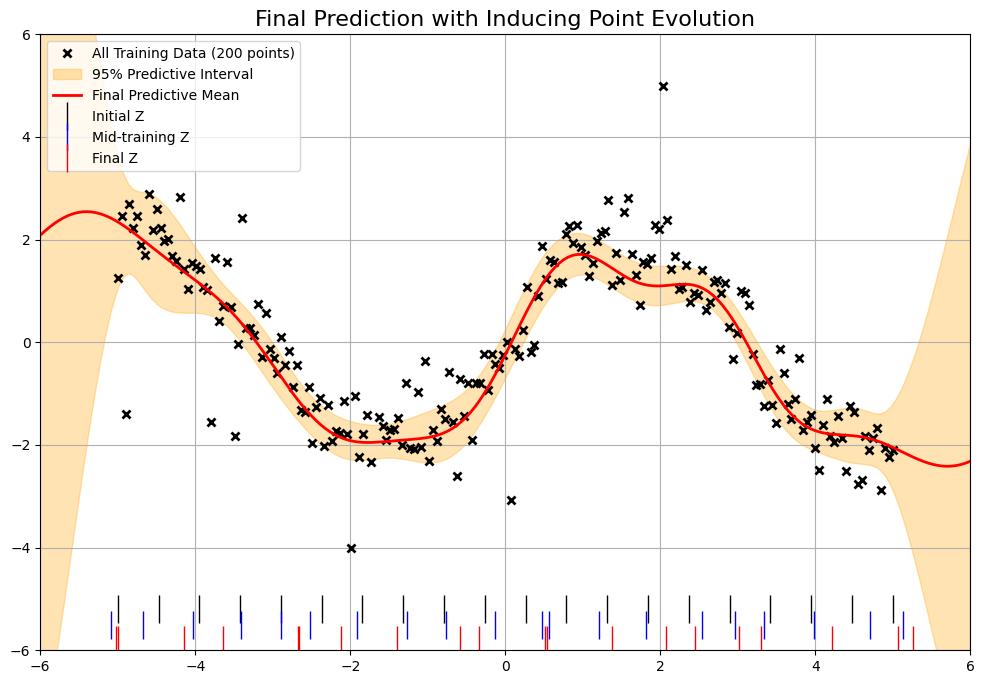

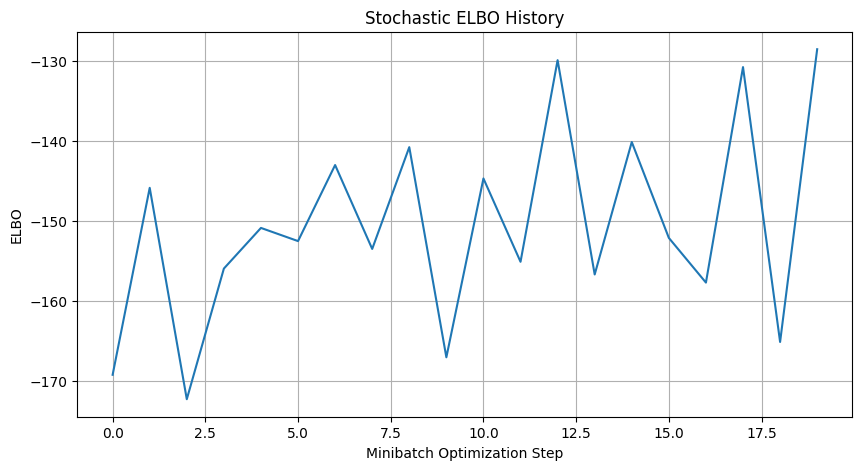

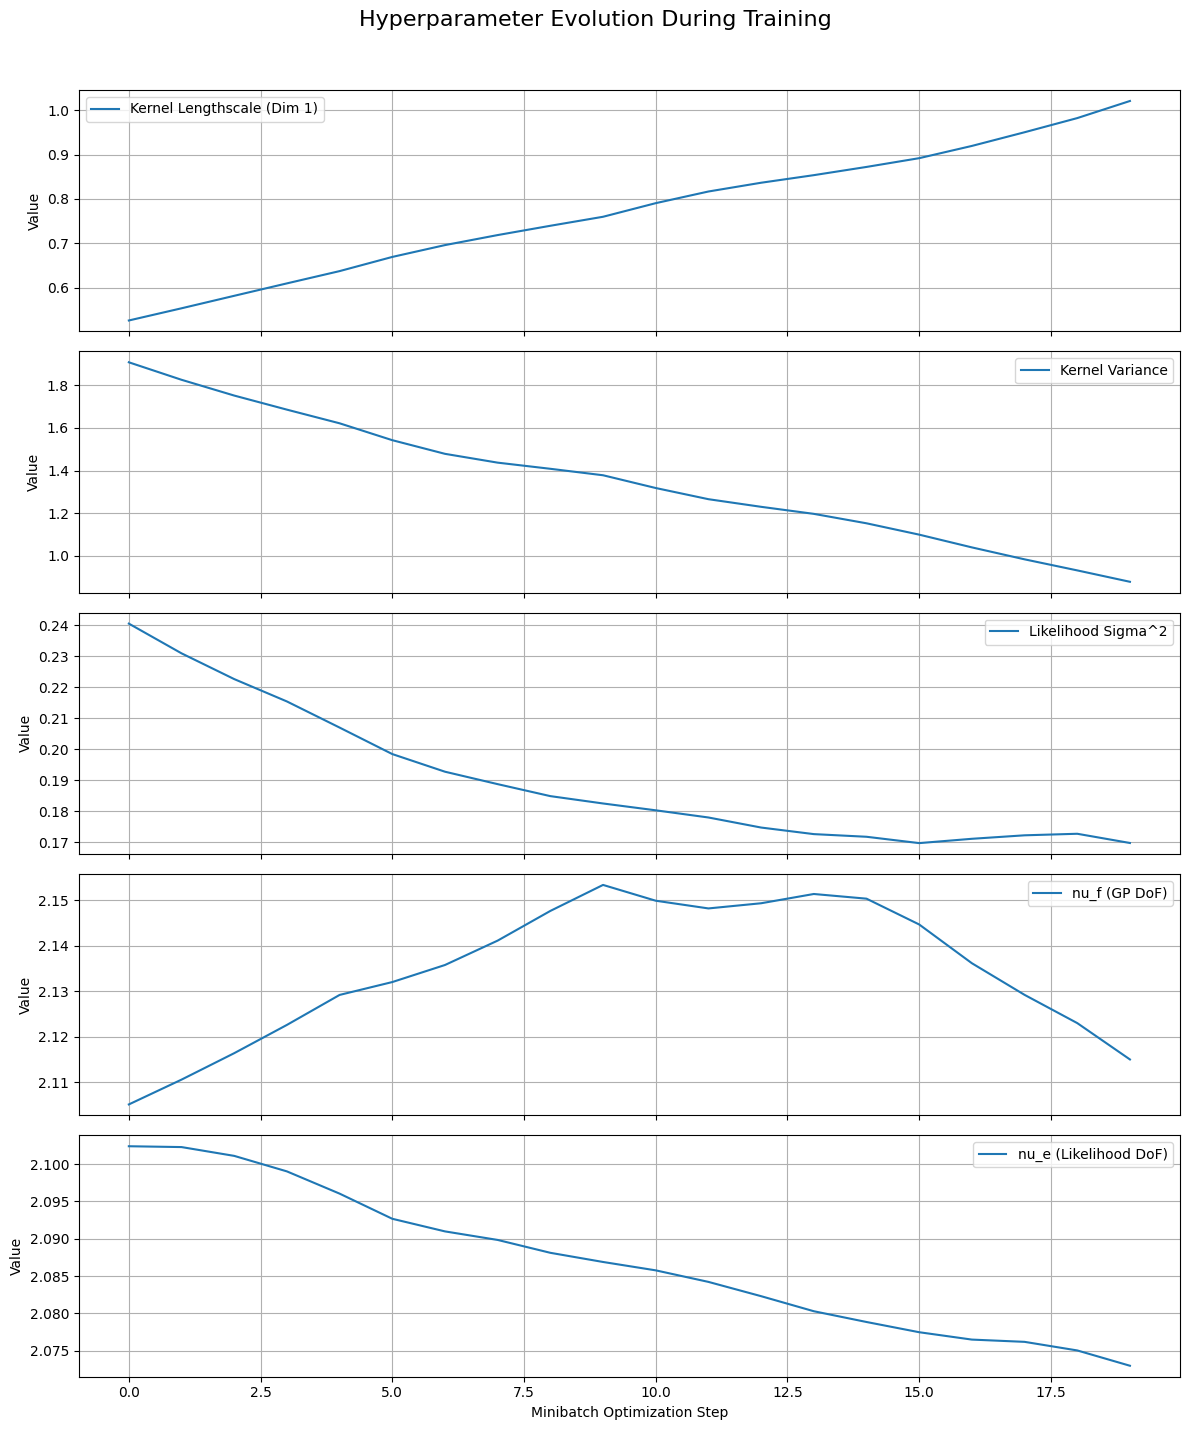

In [2]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm
import numpy as np # Import numpy for safer plotting

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class StreamingTPRegression(nn.Module):
    """
    Implements a streaming/online version of the TP Regression model.

    This version includes online optimization of all hyperparameters (kernel, noise, DoF)
    and inducing points (Z) using a nested optimization loop within the main `fit` method.
    This implementation supports ARD (Automatic Relevance Determination) for kernel lengthscales.
    """
    def __init__(self, M, D, N_total, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.M = M
        self.D = D
        self.N_total = N_total # Total size of the dataset for scaling the ELBO

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        self.Z = nn.Parameter(Z_initial.clone())
        
        # --- ARD-aware lengthscale initialization ---
        if isinstance(kernel_lengthscale, (float, int)):
            kernel_lengthscale = torch.full((D,), float(kernel_lengthscale))
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale)
            if kernel_lengthscale.numel() != D:
                raise ValueError(f"kernel_lengthscale must be a scalar or have {D} elements for ARD.")
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        
        self.log_nu_f_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_f - 2.0)))
        self.log_nu_e_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_e - 2.0)))


        # --- Global Variational Parameters ---
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M) # Cholesky of covariance S_u
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters and inducing points from storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        
        nu_f = 2.0 + torch.exp(self.log_nu_f_minus_2)
        nu_e = 2.0 + torch.exp(self.log_nu_e_minus_2)

        return lengthscale, variance, sigma_sq, nu_f, nu_e, self.Z

    def kernel(self, A, B):
        """ RBF kernel with ARD, uses current hyperparameter values. """
        lengthscale, variance, _, _, _, _ = self._get_hyperparams()
        A_scaled = A / lengthscale
        B_scaled = B / lengthscale
        sq_dist = torch.cdist(A_scaled, B_scaled, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist)

    def partial_fit(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Performs the E-Step for a minibatch.
        """
        N_batch = X_batch.shape[0]
        lengthscale, variance, sigma_sq, nu_f, nu_e, Z = self._get_hyperparams()

        Kzz = self.kernel(Z, Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(X_batch, Z)
        
        # --- EFFICIENCY IMPROVEMENT ---
        # The diagonal of K(X,X) is just the variance.
        Kxx_diag_batch = variance.expand(N_batch)

        alpha_lambda_batch = torch.ones(N_batch, 1)
        beta_lambda_batch = torch.ones(N_batch, 1)

        for _ in range(cavi_max_iter):
            alpha_lambda_old = alpha_lambda_batch.clone()
            
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f_batch = Kxz_batch @ Kzz_inv_mu
            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
            A_batch = torch.linalg.solve(Kzz, Kxz_batch.T).T
            var_f_inducing = torch.sum((A_batch @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag_batch - torch.sum(A_batch * Kxz_batch, dim=1))
            Var_q_f_batch = (var_f_prior + var_f_inducing).unsqueeze(1)
            
            alpha_lambda_batch = nu_e / 2.0 + 0.5
            expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
            beta_lambda_batch = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

            if torch.norm(alpha_lambda_batch - alpha_lambda_old) < cavi_tol:
                break
        
        E_lambda_batch = alpha_lambda_batch / beta_lambda_batch
        
        P_u_inv_S_u = torch.cholesky_solve(self.L_u @ self.L_u.T, Lzz)
        m_u_term = self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(P_u_inv_S_u) + m_u_term
        
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()
        
        E_r = self.alpha_r / self.beta_r
        P_u = E_r * torch.inverse(Kzz) + A_batch.T @ (E_lambda_batch * A_batch) / sigma_sq
        h_u = (A_batch.T * E_lambda_batch.T) @ y_batch / sigma_sq
        
        L_P = torch.linalg.cholesky(P_u + torch.eye(self.M) * 1e-6)
        S_u = torch.cholesky_solve(torch.eye(self.M), L_P)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)
        self.m_u = S_u @ h_u

        return alpha_lambda_batch, beta_lambda_batch

    def _calculate_stochastic_elbo(self, X_batch, y_batch, local_params):
        """
        Calculates the stochastic ELBO for the current minibatch.
        """
        alpha_lambda_batch, beta_lambda_batch = local_params
        N_batch = X_batch.shape[0]
        
        lengthscale, variance, sigma_sq, nu_f, nu_e, Z = self._get_hyperparams()

        Kzz = self.kernel(Z, Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(X_batch, Z)
        
        # --- EFFICIENCY IMPROVEMENT ---
        Kxx_diag = variance.expand(N_batch)

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (y_batch - E_q_f).pow(2) + Var_q_f

        E_lambda = alpha_lambda_batch / beta_lambda_batch
        E_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)

        e_log_lik = -0.5 * N_batch * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * N_batch * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)
        
        scaled_e_log_lik = e_log_lik * (self.N_total / N_batch)

        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        kl_lambda = torch.lgamma(alpha_lambda_batch) - alpha_lambda_batch * torch.log(beta_lambda_batch) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (alpha_lambda_batch - nu_e / 2) * E_log_lambda + \
                    (beta_lambda_batch - nu_e / 2) * E_lambda
        
        scaled_kl_lambda = torch.sum(kl_lambda) * (self.N_total / N_batch)

        elbo = scaled_e_log_lik - kl_u_r - scaled_kl_lambda
        return elbo

    def fit(self, X_full, y_full, num_epochs=5, batch_size=20, lr=0.01, inner_loop_max_iter=5):
        """
        Orchestrates the training process with a nested loop structure.
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        num_batches = X_full.shape[0] // batch_size
        elbo_history = []
        param_history = []
        
        print(f"Starting training for {num_epochs} epochs...")
        for epoch in range(num_epochs):
            permutation = torch.randperm(X_full.size(0))
            
            pbar = tqdm.trange(num_batches)
            pbar.set_description(f"Epoch {epoch+1}/{num_epochs}")

            for i in pbar:
                indices = permutation[i * batch_size : (i + 1) * batch_size]
                X_batch, y_batch = X_full[indices], y_full[indices]

                for _ in range(inner_loop_max_iter):
                    with torch.no_grad():
                        local_params = self.partial_fit(X_batch, y_batch)

                    optimizer.zero_grad()
                    neg_elbo = -self._calculate_stochastic_elbo(X_batch, y_batch, local_params)
                    neg_elbo.backward()
                    optimizer.step()
                
                current_elbo = -neg_elbo.item()
                elbo_history.append(current_elbo)
                
                with torch.no_grad():
                    l, v, s_sq, nf, ne, Z_current = self._get_hyperparams()
                    param_record = {
                        "lengthscale": l.clone().detach().numpy(),
                        "variance": v.item(),
                        "sigma_sq": s_sq.item(),
                        "nu_f": nf.item(),
                        "nu_e": ne.item(),
                        "inducing_points": Z_current.clone().detach().numpy()
                    }
                    param_history.append(param_record)
                
                pbar.set_postfix(ELBO=f"{current_elbo:.2f}")
        
        return elbo_history, param_history


    def predict(self, X_test):
        """ Makes predictions at new points X_test using the current global posterior. """
        with torch.no_grad():
            m_u_final = self.m_u
            L_u_final = self.L_u
            
            lengthscale, variance, sigma_sq, nu_f, nu_e, Z_final = self._get_hyperparams()
            
            K_star_z = self.kernel(X_test, Z_final)
            
            # --- EFFICIENCY IMPROVEMENT ---
            K_star_star_diag = variance.expand(X_test.shape[0])

            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            Kzz_inv_mu = torch.cholesky_solve(m_u_final, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ L_u_final)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            pred_nu = 2 * (nu_f / 2.0 + self.M / 2.0)

            return pred_mean, pred_var.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # 1. Generate data
    N_total = 200
    X_full = torch.linspace(-5, 5, N_total).unsqueeze(1)
    y_true = torch.sin(X_full) * 2
    noise = torch.randn(N_total, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N_total, 1)) * 0.5
    y_full = y_true + noise
    outlier_indices = torch.randperm(N_total)[:20]
    y_full[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_full[60] = -4.0
    y_full[140] = 5.0
    
    D = X_full.shape[1]

    # 2. Setup the streaming model
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = StreamingTPRegression(
        M=M,
        D=D,
        N_total=N_total,
        Z_initial=Z_initial,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model
    elbo_history, param_history = model.fit(X_full, y_full, num_epochs=5, batch_size=50, lr=0.01, inner_loop_max_iter=5)

    print("\n--- Finished Training ---")
    
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")
    print("\n--- Final Hyperparameters ---")
    lengthscale, variance, sigma_sq, nu_f, nu_e, _ = model._get_hyperparams()
    # This print statement should now work without error
    print(f"Lengthscale(s) (ARD): {lengthscale.detach().numpy()}")
    print(f"Variance: {variance.item():.4f}")
    print(f"Likelihood Sigma^2: {sigma_sq.item():.4f}")
    print(f"Degrees of Freedom (nu_f): {nu_f.item():.4f}")
    print(f"Degrees of Freedom (nu_e): {nu_e.item():.4f}")


    # 4. Visualize the final result with Inducing Point history
    plt.figure(figsize=(12, 8))
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean_final, pred_var_final, pred_nu_final = model.predict(X_test)
    pred_scale_final = torch.sqrt(pred_var_final)
    df_final = pred_nu_final.item()
    lower_final = pred_mean_final + t.ppf(0.025, df=df_final) * pred_scale_final
    upper_final = pred_mean_final + t.ppf(0.975, df=df_final) * pred_scale_final
    
    plt.plot(X_full, y_full, 'kx', mew=2, label=f'All Training Data ({N_total} points)')
    plt.fill_between(X_test.squeeze(), lower_final.squeeze(), upper_final.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean_final, 'r-', lw=2, label='Final Predictive Mean')
    
    # --- BUG FIX: Use NumPy for plotting helpers ---
    Z_start = Z_initial.numpy()
    Z_mid = param_history[len(param_history) // 2]['inducing_points']
    Z_final = param_history[-1]['inducing_points']
    
    plt.plot(Z_start, np.full_like(Z_start, -5.2), 'k|', ms=20, label='Initial Z')
    plt.plot(Z_mid, np.full_like(Z_mid, -5.5), 'b|', ms=20, label='Mid-training Z')
    plt.plot(Z_final, np.full_like(Z_final, -5.8), 'r|', ms=20, label='Final Z')

    plt.title(f'Final Prediction with Inducing Point Evolution', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

    # 5. Plot training history
    plt.figure(figsize=(10, 5))
    plt.plot(elbo_history)
    plt.title("Stochastic ELBO History")
    plt.xlabel("Minibatch Optimization Step")
    plt.ylabel("ELBO")
    plt.grid(True)
    plt.show()
    
    fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
    fig.suptitle("Hyperparameter Evolution During Training", fontsize=16)
    
    lengthscales_hist = [p['lengthscale'] for p in param_history]
    variances = [p['variance'] for p in param_history]
    sigma_sqs = [p['sigma_sq'] for p in param_history]
    nu_fs = [p['nu_f'] for p in param_history]
    nu_es = [p['nu_e'] for p in param_history]
    
    num_dims = lengthscales_hist[0].shape[0]
    for d in range(num_dims):
        axs[0].plot([l[d] for l in lengthscales_hist], label=f'Kernel Lengthscale (Dim {d+1})')
    axs[0].set_ylabel("Value")
    axs[0].grid(True)
    axs[0].legend()
    
    axs[1].plot(variances, label='Kernel Variance')
    axs[1].set_ylabel("Value")
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(sigma_sqs, label='Likelihood Sigma^2')
    axs[2].set_ylabel("Value")
    axs[2].grid(True)
    axs[2].legend()

    axs[3].plot(nu_fs, label='nu_f (GP DoF)')
    axs[3].set_ylabel("Value")
    axs[3].grid(True)
    axs[3].legend()
    
    axs[4].plot(nu_es, label='nu_e (Likelihood DoF)')
    axs[4].set_ylabel("Value")
    axs[4].set_xlabel("Minibatch Optimization Step")
    axs[4].grid(True)
    axs[4].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

Starting training for 100 epochs...


Epoch 1/100:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 100/100: 100%|██████████| 5/5 [00:00<00:00, 35.11it/s, BestELBO=394.53, ELBO=-417.36]



--- Finished Training ---

Best ELBO achieved: 394.5267


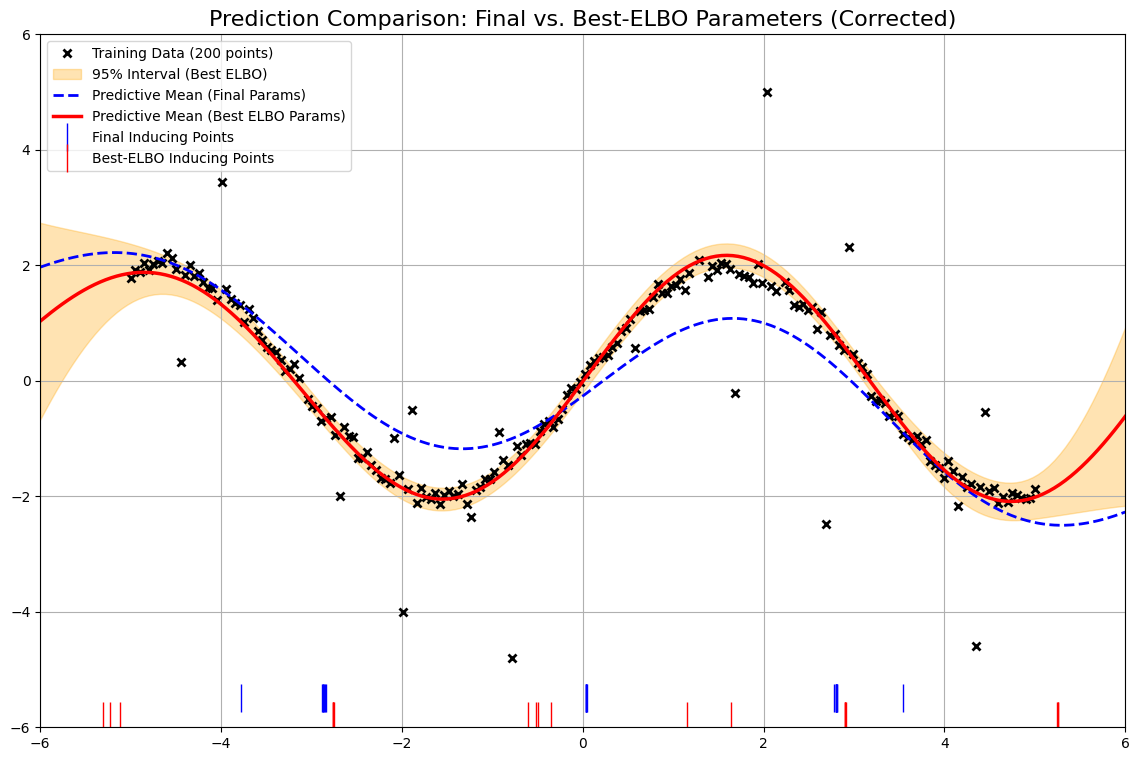

In [12]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm
import numpy as np

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class StreamingTPRegression(nn.Module):
    """
    Implements a streaming/online version of the TP Regression model.

    This version includes online optimization of all hyperparameters and inducing points.
    It supports ARD and can use the parameters corresponding to the best observed ELBO for prediction.
    """
    def __init__(self, M, D, N_total, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.M = M
        self.D = D
        self.N_total = N_total

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        self.Z = nn.Parameter(Z_initial.clone())
        
        if isinstance(kernel_lengthscale, (float, int)):
            kernel_lengthscale = torch.full((D,), float(kernel_lengthscale))
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_f - 2.0)))
        self.log_nu_e_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_e - 2.0)))

        # --- Global Variational Parameters ---
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        
        # --- State for Best ELBO Parameters ---
        self.best_elbo = -torch.inf
        self.best_params = {}

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters and inducing points from storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = 2.0 + torch.exp(self.log_nu_f_minus_2)
        nu_e = 2.0 + torch.exp(self.log_nu_e_minus_2)
        return lengthscale, variance, sigma_sq, nu_f, nu_e, self.Z

    def kernel(self, A, B):
        """ RBF kernel with ARD, uses current nn.Parameter values. """
        lengthscale, variance, _, _, _, _ = self._get_hyperparams()
        A_scaled = A / lengthscale
        B_scaled = B / lengthscale
        sq_dist = torch.cdist(A_scaled, B_scaled, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist)

    def partial_fit(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        """Performs the E-Step for a minibatch."""
        N_batch = X_batch.shape[0]
        lengthscale, variance, sigma_sq, nu_f, nu_e, Z = self._get_hyperparams()
        Kzz = self.kernel(Z, Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(X_batch, Z)
        Kxx_diag_batch = variance.expand(N_batch)
        alpha_lambda_batch = torch.ones(N_batch, 1)
        beta_lambda_batch = torch.ones(N_batch, 1)
        for _ in range(cavi_max_iter):
            alpha_lambda_old = alpha_lambda_batch.clone()
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f_batch = Kxz_batch @ Kzz_inv_mu
            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
            A_batch = torch.linalg.solve(Kzz, Kxz_batch.T).T
            var_f_inducing = torch.sum((A_batch @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag_batch - torch.sum(A_batch * Kxz_batch, dim=1))
            Var_q_f_batch = (var_f_prior + var_f_inducing).unsqueeze(1)
            alpha_lambda_batch = nu_e / 2.0 + 0.5
            expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
            beta_lambda_batch = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error
            if torch.norm(alpha_lambda_batch - alpha_lambda_old) < cavi_tol:
                break
        E_lambda_batch = alpha_lambda_batch / beta_lambda_batch
        P_u_inv_S_u = torch.cholesky_solve(self.L_u @ self.L_u.T, Lzz)
        m_u_term = self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(P_u_inv_S_u) + m_u_term
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()
        E_r = self.alpha_r / self.beta_r
        P_u = E_r * torch.inverse(Kzz) + A_batch.T @ (E_lambda_batch * A_batch) / sigma_sq
        h_u = (A_batch.T * E_lambda_batch.T) @ y_batch / sigma_sq
        L_P = torch.linalg.cholesky(P_u + torch.eye(self.M) * 1e-6)
        S_u = torch.cholesky_solve(torch.eye(self.M), L_P)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)
        self.m_u = S_u @ h_u
        return alpha_lambda_batch, beta_lambda_batch

    def _calculate_stochastic_elbo(self, X_batch, y_batch, local_params):
        """Calculates the stochastic ELBO for the current minibatch."""
        alpha_lambda_batch, beta_lambda_batch = local_params
        N_batch = X_batch.shape[0]
        lengthscale, variance, sigma_sq, nu_f, nu_e, Z = self._get_hyperparams()
        Kzz = self.kernel(Z, Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(X_batch, Z)
        Kxx_diag = variance.expand(N_batch)
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu
        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)
        expected_sq_error = (y_batch - E_q_f).pow(2) + Var_q_f
        E_lambda = alpha_lambda_batch / beta_lambda_batch
        E_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
        e_log_lik = -0.5 * N_batch * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * N_batch * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - 0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)
        scaled_e_log_lik = e_log_lik * (self.N_total / N_batch)
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + (self.alpha_r - 1) * E_log_r - self.beta_r * E_r
        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + 0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u
        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r
        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r
        kl_lambda = torch.lgamma(alpha_lambda_batch) - alpha_lambda_batch * torch.log(beta_lambda_batch) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (alpha_lambda_batch - nu_e / 2) * E_log_lambda + (beta_lambda_batch - nu_e / 2) * E_lambda
        scaled_kl_lambda = torch.sum(kl_lambda) * (self.N_total / N_batch)
        elbo = scaled_e_log_lik - kl_u_r - scaled_kl_lambda
        return elbo

    def fit(self, X_full, y_full, num_epochs=5, batch_size=20, lr=0.01, inner_loop_max_iter=5):
        """Orchestrates the training process and tracks the best parameters."""
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        num_batches = X_full.shape[0] // batch_size
        elbo_history, param_history = [], []
        
        print(f"Starting training for {num_epochs} epochs...")
        for epoch in range(num_epochs):
            permutation = torch.randperm(X_full.size(0))
            pbar = tqdm.trange(num_batches)
            pbar.set_description(f"Epoch {epoch+1}/{num_epochs}")
            for i in pbar:
                indices = permutation[i * batch_size : (i + 1) * batch_size]
                X_batch, y_batch = X_full[indices], y_full[indices]
                for _ in range(inner_loop_max_iter):
                    with torch.no_grad():
                        local_params = self.partial_fit(X_batch, y_batch)
                    optimizer.zero_grad()
                    neg_elbo = -self._calculate_stochastic_elbo(X_batch, y_batch, local_params)
                    neg_elbo.backward()
                    optimizer.step()
                
                current_elbo = -neg_elbo.item()
                elbo_history.append(current_elbo)
                
                if current_elbo > self.best_elbo:
                    self.best_elbo = current_elbo
                    with torch.no_grad():
                        l, v, s_sq, nf, ne, Z_current = self._get_hyperparams()
                        # ## FIX ##: Save the COMPLETE model state, including variational parameters
                        self.best_params = {
                            "lengthscale": l.clone(), "variance": v.clone(), 
                            "sigma_sq": s_sq.clone(), "nu_f": nf.clone(), "nu_e": ne.clone(),
                            "inducing_points": Z_current.clone(),
                            "m_u": self.m_u.clone(), "L_u": self.L_u.clone(),
                            "alpha_r": self.alpha_r.clone(), "beta_r": self.beta_r.clone()
                        }
                
                # We still record history separately for plotting hyperparameter evolution
                with torch.no_grad():
                    l, v, s_sq, nf, ne, Z_current = self._get_hyperparams()
                    param_history.append({"lengthscale": l.clone().numpy(), "variance": v.item(), "sigma_sq": s_sq.item(),
                                          "nu_f": nf.item(), "nu_e": ne.item(), "inducing_points": Z_current.clone().numpy()})
                
                pbar.set_postfix(ELBO=f"{current_elbo:.2f}", BestELBO=f"{self.best_elbo:.2f}")
        
        return elbo_history, param_history

    def predict(self, X_test, use_best_elbo_params=False):
        """Makes predictions. Can use final parameters or best-ELBO parameters."""
        with torch.no_grad():
            if use_best_elbo_params:
                if not self.best_params:
                    raise RuntimeError("No best parameters saved. Run fit() first.")
                
                # ## FIX ##: Load the COMPLETE state from the saved dictionary
                params = self.best_params
                lengthscale, variance, nu_f = params['lengthscale'], params['variance'], params['nu_f']
                Z_pred, m_pred, L_pred = params['inducing_points'], params['m_u'], params['L_u']
                alpha_r_pred, beta_r_pred = params['alpha_r'], params['beta_r']
                
                def kernel_fn(A, B):
                    A_scaled = A / lengthscale
                    B_scaled = B / lengthscale
                    sq_dist = torch.cdist(A_scaled, B_scaled, p=2).pow(2)
                    return variance * torch.exp(-0.5 * sq_dist)
            else:
                # Use the current model parameters
                lengthscale, variance, _, nu_f, _, Z_pred = self._get_hyperparams()
                m_pred, L_pred = self.m_u, self.L_u
                alpha_r_pred, beta_r_pred = self.alpha_r, self.beta_r
                kernel_fn = self.kernel

            K_star_z = kernel_fn(X_test, Z_pred)
            K_star_star_diag = variance.expand(X_test.shape[0])
            Kzz = kernel_fn(Z_pred, Z_pred) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            Kzz_inv_mu = torch.cholesky_solve(m_pred, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ L_pred)**2, dim=1)

            # Use the correct E[1/r] for the chosen state
            E_inv_r = beta_r_pred / (alpha_r_pred - 1.0) if alpha_r_pred > 1 else beta_r_pred
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            pred_nu = 2 * (nu_f / 2.0 + self.M / 2.0)

            return pred_mean, pred_var.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # (The main script block remains the same as your last version)
    # 1. Generate data
    N_total, D = 200, 1
    X_full = torch.linspace(-5, 5, N_total).unsqueeze(1)
    y_true = torch.sin(X_full) * 2
    noise = torch.randn(N_total, 1) * 0.1
    y_full = y_true + noise
    outlier_indices = torch.randperm(N_total)[:20]
    y_full[outlier_indices] += torch.distributions.StudentT(df=2).sample((20, 1)) * 1.5
    y_full[60], y_full[140] = -4.0, 5.0
    
    # 2. Setup model
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)
    model = StreamingTPRegression(M=M, D=D, N_total=N_total, Z_initial=Z_initial, nu_f=2.1,
                                  nu_e=2.1, kernel_lengthscale=0.5, kernel_variance=2.0,
                                  likelihood_sigma=0.5)

    # 3. Fit model
    elbo_history, param_history = model.fit(X_full, y_full, num_epochs=100, batch_size=40, lr=0.01, inner_loop_max_iter=5)

    print("\n--- Finished Training ---")
    print(f"\nBest ELBO achieved: {model.best_elbo:.4f}")

    # 4. Visualize results
    plt.figure(figsize=(14, 9))
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)

    # --- Prediction using FINAL parameters ---
    pred_mean_final, _, _ = model.predict(X_test, use_best_elbo_params=False)
    
    # --- Prediction using BEST-ELBO parameters ---
    pred_mean_best, pred_var_best, pred_nu_best = model.predict(X_test, use_best_elbo_params=True)
    pred_scale_best = torch.sqrt(pred_var_best)
    df_best = pred_nu_best.item()
    lower_best = pred_mean_best + t.ppf(0.025, df=df_best) * pred_scale_best
    upper_best = pred_mean_best + t.ppf(0.975, df=df_best) * pred_scale_best

    # Plotting
    plt.plot(X_full, y_full, 'kx', mew=2, label=f'Training Data ({N_total} points)')
    plt.fill_between(X_test.squeeze(), lower_best.squeeze(), upper_best.squeeze(), color='orange', alpha=0.3, label='95% Interval (Best ELBO)')
    plt.plot(X_test, pred_mean_final, 'b--', lw=2, label='Predictive Mean (Final Params)')
    plt.plot(X_test, pred_mean_best, 'r-', lw=2.5, label='Predictive Mean (Best ELBO Params)')
    
    Z_final = model.Z.detach().numpy()
    Z_best = model.best_params['inducing_points'].numpy()
    plt.plot(Z_final, np.full_like(Z_final, -5.5), 'b|', ms=20, label='Final Inducing Points')
    plt.plot(Z_best, np.full_like(Z_best, -5.8), 'r|', ms=20, label='Best-ELBO Inducing Points')
    
    plt.title('Prediction Comparison: Final vs. Best-ELBO Parameters (Corrected)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

# https://aistudio.google.com/prompts/178OUbiWc7exFycMSuUSF16DhpWZ7fiNm